
# 03 â€” Time Alignment (OHLCV â†” Quotes)

**Fecha:** 2026-02-03  
**Slice:** AABA 2019-01  
**Objetivo:** Determinar unidades de timestamp, relaciÃ³n timestamp vs participant_timestamp, y alineaciÃ³n temporal entre Quotes y OHLCV 1m; medir cobertura por sesiÃ³n.


## Que hace este notebook (explicacion Explicativa)

`03_time_coverage.ipynb` valida la **integridad temporal** entre OHLCV y Quotes para el slice del manifest.

Hace esto:

1. Carga `manifest` + `cache` y verifica que existan archivos.
2. Infiere la unidad de tiempo de `timestamp` y `participant_timestamp` (`ns/us/ms/s`) y fija `TS_UNIT` / `PTS_UNIT`.
3. Compara ambos relojes (SIP vs participant) para medir deltas y decidir el eje temporal (`TIME_AXIS`).
4. Normaliza quotes (bid/ask/ts) y los agrupa por minuto en `America/New_York`.
5. Convierte OHLCV a minuto NY y calcula cobertura por sesion regular (`09:30-16:00`, 390 minutos).
6. Calcula cobertura diaria de quotes por sesion (tambien sobre 390 minutos).
7. Alinea OHLCV vs quotes por minuto y mide violaciones donde `mid` cae fuera de `[low, high]`.
8. Exporta evidencia en `runs/data_quality/03_time_coverage/<timestamp>/`:
   - `ohlcv_session_coverage.parquet`
   - `quotes_session_coverage.parquet`
   - `mid_in_range_by_day.parquet`

En resumen: este notebook decide si la base temporal es coherente y si las barras OHLCV son compatibles con el comportamiento minuto a minuto de las quotes.


In [1]:
import json
import os
import sys
import subprocess
from pathlib import Path
from datetime import datetime

import polars as pl

# Root del repo (fijo para evitar errores de cwd)
NOTEBOOK_ID = "03_time_coverage"
PROJECT_ROOT = Path.cwd().parents[1]
os.chdir(PROJECT_ROOT)
os.environ["PYTHONPATH"] = str(PROJECT_ROOT)

# Manifest del repo
MANIFEST_PATH = PROJECT_ROOT / "data" / "manifests" / "r2_slice_AABA_2019_01.json"

# Cache real (usa el que ya tienes materializado)
os.environ["DATA_CACHE_DIR"] = r"C:\TSIS_Data\data"
CACHE_DIR = Path(os.environ["DATA_CACHE_DIR"]).resolve()

RUNS_DIR = Path(os.getenv("RUNS_DIR", PROJECT_ROOT / "runs")).resolve()

env = os.environ.copy()
env["PYTHONPATH"] = str(PROJECT_ROOT)

print("UTC now:", datetime.utcnow().isoformat(), "Z")                                                                                      
print("Manifest:", MANIFEST_PATH)                                                                                                          
print("Cache dir:", CACHE_DIR)                                                                                                             
                                                                                                                                            
if not MANIFEST_PATH.exists():                                                                                                             
    raise FileNotFoundError(f"Missing manifest: {MANIFEST_PATH}")                                                                          
if not CACHE_DIR.exists():                                                                                                                 
    resp = input("Cache dir no existe. Materializar desde R2 con r2_sync? [y/N] ")                                                         
    if resp.strip().lower() == "y":                                                                                                        
        sync_cmd = [                                                                                                                       
            sys.executable, str(PROJECT_ROOT / "scripts" / "r2_sync.py"),                                                                  
            "--manifest", str(MANIFEST_PATH),                                                                                              
        ]                                                                                                                                  
        print("SYNC:\n", " ".join(sync_cmd))                                                                                               
        subprocess.check_call(sync_cmd, cwd=str(PROJECT_ROOT), env=env)                                                                    
    if not CACHE_DIR.exists():                                                                                                             
        raise FileNotFoundError(f"Missing cache dir: {CACHE_DIR}")


UTC now: 2026-02-16T16:16:30.481406 Z
Manifest: c:\TSIS_Data\v1\backtest_SmallCaps\data\manifests\r2_slice_AABA_2019_01.json
Cache dir: C:\TSIS_Data\data


In [2]:
manifest = json.loads(MANIFEST_PATH.read_text(encoding="utf-8"))
objs = manifest["objects"]

ohlcv_keys = [o["key"] for o in objs if o["dataset"] == "ohlcv_intraday_1m"]
quote_keys = [o["key"] for o in objs if o["dataset"] == "quotes_p95"]

print("OHLCV files:", len(ohlcv_keys))
print("Quote files:", len(quote_keys))
print("Example OHLCV:", ohlcv_keys[0] if ohlcv_keys else None)
print("Example Quote:", quote_keys[0] if quote_keys else None)

assert len(ohlcv_keys) == 1, "Expected 1 monthly OHLCV parquet in this slice"
assert len(quote_keys) > 0, "Expected at least 1 quotes parquet in this slice"



OHLCV files: 1
Quote files: 21
Example OHLCV: ohlcv_intraday_1m/2019_2025/AABA/year=2019/month=01/minute.parquet
Example Quote: quotes_p95/AABA/year=2019/month=01/day=02/quotes.parquet


In [3]:
ohlcv_path = CACHE_DIR / ohlcv_keys[0]
q_path = CACHE_DIR / quote_keys[0]

df_ohlcv_head = pl.read_parquet(ohlcv_path, n_rows=5)
df_q_head = pl.read_parquet(q_path, n_rows=5)

print("OHLCV columns:", df_ohlcv_head.columns)
print("OHLCV dtypes:", df_ohlcv_head.dtypes)
print("Quotes columns:", df_q_head.columns)
print("Quotes dtypes:", df_q_head.dtypes)

df_q_head.head(3)


OHLCV columns: ['volume', 'vwap', 'open', 'close', 'high', 'low', 't', 'transactions', 'timestamp', 'ticker', 'date', 'minute']
OHLCV dtypes: [Int64, Float64, Float64, Float64, Float64, Float64, Int64, Int64, Datetime(time_unit='ms', time_zone=None), String, Date, String]
Quotes columns: ['ask_exchange', 'ask_price', 'ask_size', 'bid_exchange', 'bid_price', 'bid_size', 'conditions', 'participant_timestamp', 'sequence_number', 'timestamp', 'tape', 'indicators']
Quotes dtypes: [Int64, Float64, Int64, Int64, Float64, Int64, List(Int64), Int64, Int64, Int64, Int64, List(Int64)]


ask_exchange,ask_price,ask_size,bid_exchange,bid_price,bid_size,conditions,participant_timestamp,sequence_number,timestamp,tape,indicators
i64,f64,i64,i64,f64,i64,list[i64],i64,i64,i64,i64,list[i64]
18,57.17,200,15,56.33,700,[1],1546439400000189852,303792,1546439400060097104,3,null
12,57.17,1000,15,56.33,700,[1],1546439400297882330,305701,1546439400297899484,3,null
12,57.17,1000,2,56.38,300,[1],1546439400319048147,306018,1546439400319064390,3,null


**Helpers: inferir unidad timestamp + conversiÃ³n a datetime**

In [4]:
def infer_time_unit_from_magnitude(x: int) -> str:
    """
    Infer unit from typical epoch magnitude:
    - ns ~ 1e18
    - us ~ 1e15
    - ms ~ 1e12
    - s  ~ 1e9
    """
    ax = abs(int(x))
    if ax >= 10**17:
        return "ns"
    if ax >= 10**14:
        return "us"
    if ax >= 10**11:
        return "ms"
    return "s"


def to_datetime_series(s: pl.Series, unit: str) -> pl.Series:
    # Polars supports pl.from_epoch for s/ms/us/ns
    return pl.from_epoch(s, time_unit=unit)


def summarize_int_ts(path: Path, col: str) -> dict:
    df = pl.read_parquet(path, columns=[col])
    stats = df.select(
        pl.col(col).min().alias("min"),
        pl.col(col).max().alias("max"),
        pl.col(col).median().alias("median"),
    ).row(0)
    return {"min": int(stats[0]), "max": int(stats[1]), "median": int(stats[2])}


**Inferir unidad de timestamp y participant_timestamp (un dÃ­a)**

In [5]:
# Pick one representative quotes file (first in slice)
q0 = CACHE_DIR / quote_keys[0]

ts_stats = summarize_int_ts(q0, "timestamp")
pt_stats = summarize_int_ts(q0, "participant_timestamp")

print("timestamp stats:", ts_stats)
print("participant_timestamp stats:", pt_stats)

ts_unit_guess = infer_time_unit_from_magnitude(ts_stats["median"])
pt_unit_guess = infer_time_unit_from_magnitude(pt_stats["median"])

print("timestamp unit guess:", ts_unit_guess)
print("participant_timestamp unit guess:", pt_unit_guess)


timestamp stats: {'min': 1546439400060097104, 'max': 1546462798096767649, 'median': 1546451565478997248}
participant_timestamp stats: {'min': 1546439400000189852, 'max': 1546473600000000000, 'median': 1546451565479019776}
timestamp unit guess: ns
participant_timestamp unit guess: ns


**Validar unidad probando conversiones (ns/us/ms/s) y viendo fechas coherentes**

In [6]:
from datetime import datetime, timezone

def infer_time_unit_from_magnitude(x: int) -> str:
    ax = abs(int(x))
    if ax >= 10**17:
        return "ns"
    if ax >= 10**14:
        return "us"
    if ax >= 10**11:
        return "ms"
    return "s"

def to_py_datetime(x: int, unit: str):
    if unit == "ns":
        return datetime.fromtimestamp(x / 1_000_000_000, tz=timezone.utc)
    if unit == "us":
        return datetime.fromtimestamp(x / 1_000_000, tz=timezone.utc)
    if unit == "ms":
        return datetime.fromtimestamp(x / 1_000, tz=timezone.utc)
    return datetime.fromtimestamp(x, tz=timezone.utc)

def try_units_preview(path: Path, col: str):
    df = pl.read_parquet(path, columns=[col]).head(1000)
    s = df[col]
    mn = int(s.min())
    mx = int(s.max())
    print(f"\n[{col}] raw min={mn} max={mx}")

    guess = infer_time_unit_from_magnitude((mn + mx) // 2)
    units = [guess]  # prueba solo la unidad plausible

    for u in units:                                                                                                                        
        try:                                                                                                                               
            dmin = to_py_datetime(mn, u)                                                                                                   
            dmax = to_py_datetime(mx, u)                                                                                                   
            print(f"  unit={u}  -> min={dmin}  max={dmax}")                                                                                
        except BaseException as e:                                                                                                         
            print(f"  unit={u}  -> ERROR: {e}")                                                                                            
                                                                                                                                            
try_units_preview(q0, "timestamp")                                                                                                         
try_units_preview(q0, "participant_timestamp") 



[timestamp] raw min=1546439400060097104 max=1546439540017731916
  unit=ns  -> min=2019-01-02 14:30:00.060097+00:00  max=2019-01-02 14:32:20.017732+00:00

[participant_timestamp] raw min=1546439400000189852 max=1546473600000000000
  unit=ns  -> min=2019-01-02 14:30:00.000190+00:00  max=2019-01-03 00:00:00+00:00


**Fijar unidades definitivas (edita solo estas 2 lÃ­neas si hiciera falta)**

In [7]:
# Set final units based on the preview above.
TS_UNIT = ts_unit_guess
PTS_UNIT = pt_unit_guess

print("Final TS_UNIT:", TS_UNIT)
print("Final PTS_UNIT:", PTS_UNIT)


Final TS_UNIT: ns
Final PTS_UNIT: ns


**Comparar timestamp vs participant_timestamp: deltas (en microsegundos / milisegundos)**

In [8]:
# Load a subset (to keep it fast) - adjust n_rows if you want full day
df = pl.read_parquet(q0, columns=["timestamp", "participant_timestamp"]).head(2_000_000)

# Convert deltas to seconds as float for interpretability
# If units differ, we bring both to nanoseconds first then delta, else delta in native.
def to_ns(col: str, unit: str) -> pl.Expr:
    # convert epoch to datetime then to int ns
    return pl.from_epoch(pl.col(col), time_unit=unit).dt.epoch(time_unit="ns")

df2 = df.select(
    to_ns("timestamp", TS_UNIT).alias("ts_ns"),
    to_ns("participant_timestamp", PTS_UNIT).alias("pts_ns"),
).with_columns(
    (pl.col("pts_ns") - pl.col("ts_ns")).alias("delta_ns")
)

stats = df2.select(
    pl.col("delta_ns").min().alias("min_ns"),
    pl.col("delta_ns").median().alias("median_ns"),
    pl.col("delta_ns").quantile(0.95).alias("p95_ns"),
    pl.col("delta_ns").quantile(0.99).alias("p99_ns"),
    pl.col("delta_ns").max().alias("max_ns"),
    (pl.col("delta_ns") < 0).mean().alias("neg_ratio"),
).to_dict(as_series=False)

stats


{'min_ns': [-59907252],
 'median_ns': [-194556.0],
 'p95_ns': [-16012.0],
 'p99_ns': [-15278.0],
 'max_ns': [34199126252631],
 'neg_ratio': [0.9999060138598228]}

**Decidir eje temporal para el resto del notebook**

In [9]:
# Choose the time axis to use for alignment and coverage.
# Default: consolidated "timestamp". If you find participant_timestamp is better, switch.
TIME_AXIS = "timestamp"  # or "participant_timestamp"

print("TIME_AXIS:", TIME_AXIS)


TIME_AXIS: timestamp


**NormalizaciÃ³n quotes + bucketing a minuto NY**

In [10]:
def normalize_quotes(df: pl.DataFrame) -> pl.DataFrame:
    out = df
    if "bid" not in out.columns and "bid_price" in out.columns:
        out = out.rename({"bid_price": "bid"})
    if "ask" not in out.columns and "ask_price" in out.columns:
        out = out.rename({"ask_price": "ask"})
    return out


def quotes_to_minute_buckets(path: Path) -> pl.DataFrame:
    cols = ["bid_price", "ask_price", "timestamp", "participant_timestamp"]
    df = pl.read_parquet(path, columns=[c for c in cols if c in pl.read_parquet(path, n_rows=1).columns])
    df = normalize_quotes(df)

    unit = TS_UNIT if TIME_AXIS == "timestamp" else PTS_UNIT
    ts_col = "timestamp" if TIME_AXIS == "timestamp" else "participant_timestamp"

    # Convert to NY time and floor to minute
    df = df.with_columns(
        pl.from_epoch(pl.col(ts_col), time_unit=unit)
        .dt.replace_time_zone("UTC")
        .dt.convert_time_zone("America/New_York")
        .alias("dt_ny")
    ).with_columns(
        pl.col("dt_ny").dt.truncate("1m").alias("minute_ny")
    )

    # Keep last quote in the minute (by dt_ny)
    df = df.sort("dt_ny").group_by("minute_ny").agg(
        pl.last("bid").alias("bid"),
        pl.last("ask").alias("ask"),
        pl.len().alias("n_quotes_in_minute"),
    )

    return df


**OHLCV: convertir a minuto NY y preparar tabla por minuto**

Nota: aquÃ­ asumimos que OHLCV tiene una columna temporal detectable. Si no sabes el nombre, lo inspeccionamos y ajustamos.

In [11]:
# --- OHLCV: detect timestamp column + convert to NY minute buckets (robust) ---

ohlcv_schema = pl.read_parquet(ohlcv_path, n_rows=1).schema
print("OHLCV schema:", ohlcv_schema)

# Detect candidate timestamp column
for candidate in ["ts", "timestamp", "datetime", "time", "t"]:
    if candidate in ohlcv_schema:
        OHLCV_TS_COL = candidate
        break
else:
    raise ValueError(f"No OHLCV timestamp column found. Columns: {list(ohlcv_schema.keys())}")

print("OHLCV_TS_COL:", OHLCV_TS_COL)
print("OHLCV_TS_DTYPE:", ohlcv_schema[OHLCV_TS_COL])

df_ohlcv = pl.read_parquet(ohlcv_path)

ts_dtype = ohlcv_schema[OHLCV_TS_COL]

if ts_dtype in (pl.Int64, pl.Int32, pl.UInt64, pl.UInt32):
    # epoch integer
    df_ohlcv = df_ohlcv.with_columns(
        pl.from_epoch(pl.col(OHLCV_TS_COL), time_unit=TS_UNIT)
        .dt.replace_time_zone("UTC")
        .dt.convert_time_zone("America/New_York")
        .alias("dt_ny")
    )
elif ts_dtype in (pl.Datetime,):
    # datetime without timezone; assume UTC then convert
    df_ohlcv = df_ohlcv.with_columns(
        pl.col(OHLCV_TS_COL)
        .dt.replace_time_zone("UTC")
        .dt.convert_time_zone("America/New_York")
        .alias("dt_ny")
    )
else:
    raise TypeError(f"Unsupported OHLCV timestamp dtype: {ts_dtype}")

df_ohlcv = df_ohlcv.with_columns(
    pl.col("dt_ny").dt.truncate("1m").alias("minute_ny")
)

df_ohlcv.select(["minute_ny", "open", "high", "low", "close", "volume"]).head()


OHLCV schema: Schema([('volume', Int64), ('vwap', Float64), ('open', Float64), ('close', Float64), ('high', Float64), ('low', Float64), ('t', Int64), ('transactions', Int64), ('timestamp', Datetime(time_unit='ms', time_zone=None)), ('ticker', String), ('date', Date), ('minute', String)])
OHLCV_TS_COL: timestamp
OHLCV_TS_DTYPE: Datetime(time_unit='ms', time_zone=None)


minute_ny,open,high,low,close,volume
"datetime[ms, America/New_York]",f64,f64,f64,f64,i64
2019-01-02 08:26:00 EST,57.0,57.0,57.0,57.0,1000
2019-01-02 08:47:00 EST,57.16,57.16,57.16,57.16,188
2019-01-02 08:50:00 EST,57.94,57.94,57.94,57.94,11114
2019-01-02 09:30:00 EST,56.78,56.97,56.72,56.72,22833
2019-01-02 09:31:00 EST,56.74,56.84,56.57,56.59,21724


**Cobertura por sesiÃ³n: OHLCV (09:30â€“16:00 NY)**

In [12]:
SESSION_START = (9, 30)
SESSION_END = (16, 0)

df_ohlcv_session = (
    df_ohlcv.with_columns(
        pl.col("minute_ny").dt.date().alias("date_ny"),
        pl.col("minute_ny").dt.hour().alias("hour"),
        pl.col("minute_ny").dt.minute().alias("minute"),
    )
    # start >= 09:30
    .filter(
        (pl.col("hour") > SESSION_START[0])
        | ((pl.col("hour") == SESSION_START[0]) & (pl.col("minute") >= SESSION_START[1]))
    )
    # end < 16:00
    .filter(
        (pl.col("hour") < SESSION_END[0])
        | ((pl.col("hour") == SESSION_END[0]) & (pl.col("minute") < SESSION_END[1]))
    )
)

ohlcv_cov = (
    df_ohlcv_session.group_by("date_ny")
    .agg(pl.n_unique("minute_ny").alias("minutes_present"))
    .with_columns((pl.col("minutes_present") / 390.0).alias("coverage"))
    .sort("date_ny")
)

print("OHLCV coverage (first 10 days):")
display(ohlcv_cov.head(10))

print("\nOHLCV coverage summary:")
display(ohlcv_cov.select("coverage").describe())



OHLCV coverage (first 10 days):


date_ny,minutes_present,coverage
date,u32,f64
2019-01-02,390,1.0
2019-01-03,390,1.0
2019-01-04,390,1.0
2019-01-07,390,1.0
2019-01-08,390,1.0
2019-01-09,390,1.0
2019-01-10,390,1.0
2019-01-11,389,0.997436
2019-01-14,389,0.997436



OHLCV coverage summary:


statistic,coverage
str,f64
"""count""",21.0
"""null_count""",0.0
"""mean""",0.999512
"""std""",0.001032
"""min""",0.997436
"""25%""",1.0
"""50%""",1.0
"""75%""",1.0
"""max""",1.0


In [13]:
def quotes_coverage_for_key(key: str) -> dict:
    p = CACHE_DIR / key

    # Read minimal columns to diagnose representativeness and intraday span
    base_cols = ["timestamp", "participant_timestamp", "bid_price", "ask_price", "bid", "ask"]
    cols = [c for c in base_cols if c in pl.read_parquet(p, n_rows=1).columns]
    raw = pl.read_parquet(p, columns=cols)
    raw = normalize_quotes(raw)

    unit = TS_UNIT if TIME_AXIS == "timestamp" else PTS_UNIT
    ts_col = "timestamp" if TIME_AXIS == "timestamp" else "participant_timestamp"

    raw = raw.with_columns(
        pl.from_epoch(pl.col(ts_col), time_unit=unit)
        .dt.replace_time_zone("UTC")
        .dt.convert_time_zone("America/New_York")
        .alias("ts_ny")
    )

    qm = quotes_to_minute_buckets(p).with_columns(
        pl.col("minute_ny").dt.date().alias("date_ny"),
        pl.col("minute_ny").dt.hour().alias("hour"),
        pl.col("minute_ny").dt.minute().alias("minute"),
    )

    qm_sess = qm.filter(
        (pl.col("hour") > SESSION_START[0])
        | ((pl.col("hour") == SESSION_START[0]) & (pl.col("minute") >= SESSION_START[1]))
    ).filter(
        (pl.col("hour") < SESSION_END[0])
        | ((pl.col("hour") == SESSION_END[0]) & (pl.col("minute") < SESSION_END[1]))
    )

    mins = qm_sess.select(pl.n_unique("minute_ny").alias("quote_minutes_present")).row(0)[0]
    date = qm_sess.select(pl.col("date_ny").min().alias("date_ny")).row(0)[0]

    st = raw.select([
        pl.len().alias("quote_rows"),
        pl.col("ts_ny").min().alias("min_ts_ny"),
        pl.col("ts_ny").max().alias("max_ts_ny"),
    ]).row(0)

    qrows = int(st[0])
    return {
        "key": key,
        "date_ny": date,
        "quote_minutes_present": int(mins),
        "coverage": float(mins) / 390.0,
        "quote_rows": qrows,
        "min_ts_ny": st[1],
        "max_ts_ny": st[2],
        "is_exact_50k": bool(qrows == 50000),
    }

rows = [quotes_coverage_for_key(k) for k in quote_keys]
quotes_cov = pl.DataFrame(rows).sort("date_ny")

print("Quotes coverage (first 10 days):")
display(quotes_cov.head(10))

print()
print("Quotes coverage summary:")
display(quotes_cov.select("coverage").describe())

print()
print("Low-coverage days (<0.90):")
display(quotes_cov.filter(pl.col("coverage") < 0.90).select([
    "date_ny", "quote_rows", "quote_minutes_present", "coverage", "min_ts_ny", "max_ts_ny", "is_exact_50k"
]).sort("date_ny"))

print()
print("Exact-50k files (truncation suspect):")
display(quotes_cov.filter(pl.col("is_exact_50k")).select([
    "date_ny", "quote_rows", "quote_minutes_present", "coverage", "min_ts_ny", "max_ts_ny"
]).sort("date_ny"))


Quotes coverage (first 10 days):


key,date_ny,quote_minutes_present,coverage,quote_rows,min_ts_ny,max_ts_ny,is_exact_50k
str,date,i64,f64,i64,"datetime[μs, America/New_York]","datetime[μs, America/New_York]",bool
"""quotes_p95/AABA/year=2019/mont…",2019-01-02,390,1.0,159598,2019-01-02 09:30:00.060097 EST,2019-01-02 15:59:58.096767 EST,false
"""quotes_p95/AABA/year=2019/mont…",2019-01-03,124,0.317949,50000,2019-01-03 09:30:00.003479 EST,2019-01-03 11:33:15.679698 EST,true
"""quotes_p95/AABA/year=2019/mont…",2019-01-04,82,0.210256,50000,2019-01-04 09:30:00.327133 EST,2019-01-04 10:51:20.730579 EST,true
"""quotes_p95/AABA/year=2019/mont…",2019-01-07,390,1.0,161264,2019-01-07 09:30:00.929346 EST,2019-01-07 15:59:59.817702 EST,false
"""quotes_p95/AABA/year=2019/mont…",2019-01-08,390,1.0,158881,2019-01-08 09:30:00.246928 EST,2019-01-08 15:59:58.093463 EST,false
"""quotes_p95/AABA/year=2019/mont…",2019-01-09,390,1.0,215085,2019-01-09 09:30:00.050627 EST,2019-01-09 15:59:59.739220 EST,false
"""quotes_p95/AABA/year=2019/mont…",2019-01-10,100,0.25641,50000,2019-01-10 09:30:00.040090 EST,2019-01-10 11:09:33.669717 EST,true
"""quotes_p95/AABA/year=2019/mont…",2019-01-11,390,1.0,117594,2019-01-11 09:30:00.061195 EST,2019-01-11 15:59:59.889372 EST,false
"""quotes_p95/AABA/year=2019/mont…",2019-01-14,390,1.0,127937,2019-01-14 09:30:00.210576 EST,2019-01-14 15:59:59.906577 EST,false



Quotes coverage summary:


statistic,coverage
str,f64
"""count""",21.0
"""null_count""",0.0
"""mean""",0.82381
"""std""",0.323416
"""min""",0.210256
"""25%""",1.0
"""50%""",1.0
"""75%""",1.0
"""max""",1.0



Low-coverage days (<0.90):


date_ny,quote_rows,quote_minutes_present,coverage,min_ts_ny,max_ts_ny,is_exact_50k
date,i64,i64,f64,"datetime[μs, America/New_York]","datetime[μs, America/New_York]",bool
2019-01-03,50000,124,0.317949,2019-01-03 09:30:00.003479 EST,2019-01-03 11:33:15.679698 EST,true
2019-01-04,50000,82,0.210256,2019-01-04 09:30:00.327133 EST,2019-01-04 10:51:20.730579 EST,true
2019-01-10,50000,100,0.25641,2019-01-10 09:30:00.040090 EST,2019-01-10 11:09:33.669717 EST,true
2019-01-15,50000,100,0.25641,2019-01-15 09:30:00.781107 EST,2019-01-15 11:09:12.326839 EST,true
2019-01-17,50000,101,0.258974,2019-01-17 09:30:00.011756 EST,2019-01-17 11:10:05.851983 EST,true



Exact-50k files (truncation suspect):


date_ny,quote_rows,quote_minutes_present,coverage,min_ts_ny,max_ts_ny
date,i64,i64,f64,"datetime[μs, America/New_York]","datetime[μs, America/New_York]"
2019-01-03,50000,124,0.317949,2019-01-03 09:30:00.003479 EST,2019-01-03 11:33:15.679698 EST
2019-01-04,50000,82,0.210256,2019-01-04 09:30:00.327133 EST,2019-01-04 10:51:20.730579 EST
2019-01-10,50000,100,0.25641,2019-01-10 09:30:00.040090 EST,2019-01-10 11:09:33.669717 EST
2019-01-15,50000,100,0.25641,2019-01-15 09:30:00.781107 EST,2019-01-15 11:09:12.326839 EST
2019-01-17,50000,101,0.258974,2019-01-17 09:30:00.011756 EST,2019-01-17 11:10:05.851983 EST


### Lectura Explicativa (Cobertura de Quotes por Dia)

- Aqui medimos **cuantos minutos de quotes hay realmente** por dia de sesion (sobre 390 esperados).
- Resultado observado: hay 5 dias con cobertura muy baja y exactamente 50,000 filas.
- Interpretacion: este patron no parece aleatorio; sugiere truncado operativo de archivo.
- Impacto: cualquier metrica posterior de coherencia puntual debe leerse condicionada a esta falta de muestra.


**Alineaci?n OHLCV ? Quotes: mid dentro de [low, high] + resumen**

Nota metodol?gica clave:
- Esta prueba usa `mid_t = (bid_t + ask_t)/2` del **?ltimo quote del minuto** (`last`), que es una m?trica estricta de punto.
- Para evitar sesgo por muestra parcial, por defecto se eval?an **todos los d?as del slice** (`SUBSET_DAYS = 0`).


In [14]:
# OHLCV per-minute range
ohlcv_min = df_ohlcv.select("minute_ny", "high", "low")

# Build Quotes per-minute mids by concatenating day files.
# IMPORTANT: keep 0 by default to evaluate the full slice (all days).
SUBSET_DAYS = 0  # 0 = all days
keys_to_use = quote_keys if SUBSET_DAYS == 0 else quote_keys[:SUBSET_DAYS]

if SUBSET_DAYS != 0:
    print(f"[WARN] Running alignment on subset only: first {SUBSET_DAYS} days")
else:
    print(f"Running alignment on full slice: {len(keys_to_use)} quote day-files")

qmins = []
for k in keys_to_use:
    qm = quotes_to_minute_buckets(CACHE_DIR / k).with_columns(
        ((pl.col("bid") + pl.col("ask")) / 2.0).alias("mid")
    ).select("minute_ny", "mid", "n_quotes_in_minute")
    qmins.append(qm)

quotes_min = pl.concat(qmins, how="vertical")

# --- IMPORTANT: align join key dtypes (precision + timezone) ---
TARGET_DT = pl.Datetime("ns", time_zone="America/New_York")

ohlcv_min = ohlcv_min.with_columns(pl.col("minute_ny").cast(TARGET_DT))
quotes_min = quotes_min.with_columns(pl.col("minute_ny").cast(TARGET_DT))

# Join
joined = ohlcv_min.join(quotes_min, on="minute_ny", how="inner")

EPS = 1e-9
res = joined.with_columns([
    ((pl.col("mid") < (pl.col("low") - EPS)) | (pl.col("mid") > (pl.col("high") + EPS))).alias("violation"),
    pl.when(pl.col("mid") < pl.col("low")).then(pl.col("low") - pl.col("mid"))
    .when(pl.col("mid") > pl.col("high")).then(pl.col("mid") - pl.col("high"))
    .otherwise(pl.lit(0.0)).alias("out_dist_abs"),
    (pl.col("high") - pl.col("low")).alias("hl_range"),
])

res = res.with_columns([
    pl.when(pl.col("violation") & (pl.col("hl_range") > EPS))
    .then(pl.col("out_dist_abs") / (pl.col("hl_range") + EPS))
    .otherwise(pl.lit(0.0)).alias("d_norm"),
])

summary = res.select([
    pl.len().alias("minutes_joined"),
    pl.sum("violation").alias("violations"),
    (pl.sum("violation") / pl.len()).alias("violation_ratio"),
    (1.0 - (pl.sum("violation") / pl.len())).alias("p_in_range"),
    pl.mean("n_quotes_in_minute").alias("avg_quotes_per_minute"),
    pl.quantile("out_dist_abs", 0.95, "nearest").alias("out_dist_abs_p95"),
    pl.quantile("d_norm", 0.95, "nearest").alias("d_norm_p95"),
])

print("Alignment summary (mid-in-range):")
display(summary)


Running alignment on full slice: 21 quote day-files
Alignment summary (mid-in-range):


minutes_joined,violations,violation_ratio,p_in_range,avg_quotes_per_minute,out_dist_abs_p95,d_norm_p95
u32,u32,f64,f64,f64,f64,f64
6744,1300,0.192764,0.807236,498.074437,0.01,0.285714


### Lectura Explicativa (Resumen de Alineacion Puntual)

- `violation_ratio` mide el porcentaje de minutos donde el `last_mid` queda fuera de `[low, high]`.
- Este es un criterio estricto de punto-a-rango: sensible a micro-movimientos de ticks.
- Si esta metrica sale alta, no implica automaticamente corrupcion de OHLCV.
: Puede deberse a microestructura, spread y definicion estricta del comparador.


**Violations por d?a + resumen (sin Expr.describe)**

Lectura recomendada:
- `violation_ratio` alto con cobertura baja sugiere sesgo de muestra.
- `violation_ratio` alto con cobertura alta sugiere desalineaci?n puntual real (microestructura / definici?n estricta de punto).
- Revisar siempre `coverage` y `is_exact_50k` junto a violaciones.


In [15]:
res_by_day = (
    res.with_columns(pl.col("minute_ny").dt.date().alias("date_ny"))
    .group_by("date_ny")
    .agg([
        pl.len().alias("minutes_joined"),
        pl.sum("violation").alias("violations"),
        (pl.sum("violation") / pl.len()).alias("violation_ratio"),
        pl.quantile("out_dist_abs", 0.95, "nearest").alias("out_dist_abs_p95"),
        pl.quantile("d_norm", 0.95, "nearest").alias("d_norm_p95"),
    ])
    .sort("date_ny")
)

# Join with sample representativeness diagnostics from quotes coverage
res_diag = (
    res_by_day
    .join(
        quotes_cov.select(["date_ny", "coverage", "quote_rows", "is_exact_50k"]),
        on="date_ny",
        how="left",
    )
    .sort("date_ny")
)

print("Violations by day (all days):")
display(res_diag)

print()
print("Worst violation days:")
display(res_diag.sort("violation_ratio", descending=True).head(10))

print()
print("Violation ratio summary:")
display(res_diag.select("violation_ratio").describe())

print()
print("Correlation(coverage, violation_ratio):")
corr = res_diag.select(pl.corr("coverage", "violation_ratio").alias("corr"))
display(corr)

# Sensitivity: excluding exact-50k truncation days
trunc_days = quotes_cov.filter(pl.col("is_exact_50k")).select("date_ny").to_series().to_list()
res_no_trunc = res_diag.filter(~pl.col("date_ny").is_in(trunc_days))

sens = pl.DataFrame([
    {
        "sample": "full_days",
        "n_days": int(res_diag.height),
        "minutes_joined": int(res_diag.select(pl.sum("minutes_joined")).row(0)[0]),
        "violations": int(res_diag.select(pl.sum("violations")).row(0)[0]),
        "violation_ratio": float(res_diag.select((pl.sum("violations") / pl.sum("minutes_joined")).alias("r")).row(0)[0]),
        "coverage_mean": float(res_diag.select(pl.mean("coverage")).row(0)[0]),
    },
    {
        "sample": "no_trunc_days",
        "n_days": int(res_no_trunc.height),
        "minutes_joined": int(res_no_trunc.select(pl.sum("minutes_joined")).row(0)[0]),
        "violations": int(res_no_trunc.select(pl.sum("violations")).row(0)[0]),
        "violation_ratio": float(res_no_trunc.select((pl.sum("violations") / pl.sum("minutes_joined")).alias("r")).row(0)[0]),
        "coverage_mean": float(res_no_trunc.select(pl.mean("coverage")).row(0)[0]),
    },
])

print()
print("Sensitivity (full vs no trunc days):")
display(sens)


Violations by day (all days):


date_ny,minutes_joined,violations,violation_ratio,out_dist_abs_p95,d_norm_p95,coverage,quote_rows,is_exact_50k
date,u32,u32,f64,f64,f64,f64,i64,bool
2019-01-02,390,63,0.161538,0.005,0.166667,1.0,159598,false
2019-01-03,124,27,0.217742,0.01,0.1875,0.317949,50000,true
2019-01-04,82,12,0.146341,0.01,0.1,0.210256,50000,true
2019-01-07,390,83,0.212821,0.01,0.25,1.0,161264,false
2019-01-08,390,81,0.207692,0.015,0.333333,1.0,158881,false
…,…,…,…,…,…,…,…,…
2019-01-25,390,53,0.135897,0.005,0.25,1.0,245270,false
2019-01-28,390,85,0.217949,0.01,0.5,1.0,188031,false
2019-01-29,389,99,0.254499,0.01,0.5,1.0,119021,false



Worst violation days:


date_ny,minutes_joined,violations,violation_ratio,out_dist_abs_p95,d_norm_p95,coverage,quote_rows,is_exact_50k
date,u32,u32,f64,f64,f64,f64,i64,bool
2019-01-23,390,109,0.279487,0.015,0.5,1.0,223011,false
2019-01-29,389,99,0.254499,0.01,0.5,1.0,119021,false
2019-01-14,389,96,0.246787,0.0123,0.5,1.0,127937,false
2019-01-11,389,90,0.231362,0.01,0.5,1.0,117594,false
2019-01-28,390,85,0.217949,0.01,0.5,1.0,188031,false
2019-01-03,124,27,0.217742,0.01,0.1875,0.317949,50000,true
2019-01-07,390,83,0.212821,0.01,0.25,1.0,161264,false
2019-01-08,390,81,0.207692,0.015,0.333333,1.0,158881,false
2019-01-18,390,81,0.207692,0.01,0.25,1.0,190022,false



Violation ratio summary:


statistic,violation_ratio
str,f64
"""count""",21.0
"""null_count""",0.0
"""mean""",0.188297
"""std""",0.045786
"""min""",0.1
"""25%""",0.146341
"""50%""",0.182051
"""75%""",0.217742
"""max""",0.279487



Correlation(coverage, violation_ratio):


corr
f64
0.262269



Sensitivity (full vs no trunc days):


sample,n_days,minutes_joined,violations,violation_ratio,coverage_mean
str,i64,i64,i64,f64,f64
"""full_days""",21,6744,1300,0.192764,0.82381
"""no_trunc_days""",16,6237,1213,0.194485,1.0


### Lectura Explicativa (Diagnostico Diario + Sensibilidad)

- `res_diag` permite ver por dia si las violaciones se concentran en dias truncados o no.
- El bloque de sensibilidad (`full_days` vs `no_trunc_days`) separa causalidad:
: Si cambia mucho al excluir truncados => dominaba problema de muestra.
: Si cambia poco => existe componente puntual/microestructural adicional.
- En este run, la cobertura mejora fuerte al excluir truncados, pero `violation_ratio` casi no mejora.


**Guardar artefactos (evidencia) + prints**

### Interpretacion final de resultados

Con los artefactos exportados, la lectura operativa es:

- Primero evaluar **representatividad de muestra** (`coverage`, `quote_rows`, `is_exact_50k`).
- Despues evaluar **coherencia puntual** (`violation_ratio`) y **severidad** (`out_dist_abs_p95`, `d_norm_p95`).
- Si hay dias truncados (cap de filas + corte horario temprano), no interpretar `violation_ratio` sin condicionarlo por ese sesgo.
- Si al excluir truncados la conclusion no cambia, el driver principal es microestructura/definicion de metrica; si cambia fuerte, el driver era muestra incompleta.

Este notebook actua como gate temporal previo a cualquier decision de produccion.


In [16]:
OUT = RUNS_DIR / "data_quality" / NOTEBOOK_ID / datetime.utcnow().strftime("%Y%m%d_%H%M%S")
OUT.mkdir(parents=True, exist_ok=True)

ohlcv_cov.write_parquet(OUT / "ohlcv_session_coverage.parquet")
quotes_cov.write_parquet(OUT / "quotes_session_coverage.parquet")
res_diag.write_parquet(OUT / "mid_in_range_by_day.parquet")
sens.write_parquet(OUT / "sensitivity_no_trunc.parquet")

# Decision summary (sample vs coherence)
def grade(metric: float, pass_thr: float, warn_thr: float, higher_is_better: bool = True) -> str:
    if higher_is_better:
        if metric >= pass_thr:
            return "PASS"
        if metric >= warn_thr:
            return "WARN"
        return "FAIL"
    if metric <= pass_thr:
        return "PASS"
    if metric <= warn_thr:
        return "WARN"
    return "FAIL"

coverage_mean = float(quotes_cov.select(pl.mean("coverage")).row(0)[0])
violation_ratio_full = float(res_diag.select((pl.sum("violations") / pl.sum("minutes_joined")).alias("r")).row(0)[0])
truncated_days = int(quotes_cov.filter(pl.col("is_exact_50k")).height)

sample_status = grade(coverage_mean, pass_thr=0.95, warn_thr=0.90, higher_is_better=True)
coherence_status = grade(violation_ratio_full, pass_thr=0.05, warn_thr=0.20, higher_is_better=False)
rank = {"PASS": 0, "WARN": 1, "FAIL": 2}
overall = max([sample_status, coherence_status], key=lambda s: rank[s])

applicability_status = "APPLICABLE"
root_causes = []
if sample_status in {"WARN", "FAIL"}:
    root_causes.append("sample_issue")
if coherence_status in {"WARN", "FAIL"}:
    root_causes.append("microstructure_friction")
root_cause = ",".join(root_causes) if root_causes else "none"

gate_breakdown = [
    {
        "gate": "sample_representativeness",
        "status": sample_status,
        "metric": "coverage_mean",
        "value": coverage_mean,
        "pass_thr": 0.95,
        "warn_thr": 0.90,
        "higher_is_better": True,
    },
    {
        "gate": "point_coherence",
        "status": coherence_status,
        "metric": "violation_ratio_full",
        "value": violation_ratio_full,
        "pass_thr": 0.05,
        "warn_thr": 0.20,
        "higher_is_better": False,
    },
]

ticker_val = str(globals().get("TICKER", globals().get("SYMBOL", "AABA")))
decision_table = [{
    "ticker": ticker_val,
    "applicability_status": applicability_status,
    "overall_status": overall,
    "root_cause": root_cause,
    "coverage_mean": coverage_mean,
    "violation_ratio_full": violation_ratio_full,
    "truncated_days_exact_50k": truncated_days,
    "decision": overall,
}]

decisions = {
    # Legacy fields (backward compatible)
    "metrics": {
        "coverage_mean": coverage_mean,
        "violation_ratio_full": violation_ratio_full,
        "truncated_days_exact_50k": truncated_days,
    },
    "status": {
        "sample_representativeness": sample_status,
        "time_alignment_coherence": coherence_status,
        "overall": overall,
    },
    # Homologated fields
    "applicability_status": applicability_status,
    "overall_status": overall,
    "root_cause": root_cause,
    "gate_breakdown": gate_breakdown,
    "decision_table": decision_table,
}

(Path(OUT) / "decisions_03.json").write_text(json.dumps(decisions, indent=2), encoding="utf-8")

print("Saved artifacts:")
print("-", OUT / "ohlcv_session_coverage.parquet")
print("-", OUT / "quotes_session_coverage.parquet")
print("-", OUT / "mid_in_range_by_day.parquet")
print("-", OUT / "sensitivity_no_trunc.parquet")
print("-", OUT / "decisions_03.json")
print()
print("Decision summary:")
print(decisions)


Saved artifacts:
- C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\03_time_coverage\20260216_161633\ohlcv_session_coverage.parquet
- C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\03_time_coverage\20260216_161633\quotes_session_coverage.parquet
- C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\03_time_coverage\20260216_161633\mid_in_range_by_day.parquet
- C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\03_time_coverage\20260216_161633\sensitivity_no_trunc.parquet
- C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\03_time_coverage\20260216_161633\decisions_03.json

Decision summary:
{'metrics': {'coverage_mean': 0.8238095238095239, 'violation_ratio_full': 0.19276393831553973, 'truncated_days_exact_50k': 5}, 'status': {'sample_representativeness': 'FAIL', 'time_alignment_coherence': 'WARN', 'overall': 'FAIL'}}


### Diagnostico Visual (Cobertura y Alineacion)

Este bloque traduce los resultados a graficos para identificar rapidamente:
- donde falta muestra (coverage),
- donde sube la desalineacion puntual (violation_ratio),
- y si ambos fenomenos se mueven juntos o no.


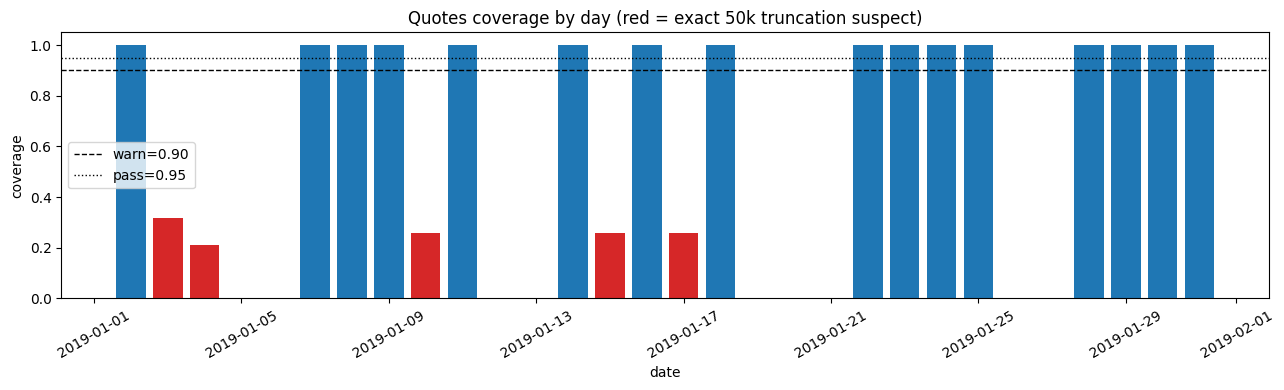

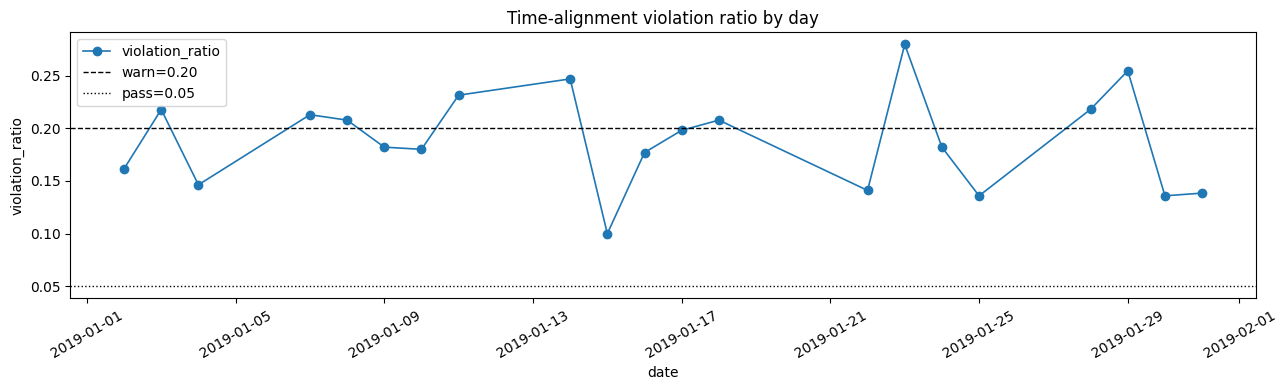

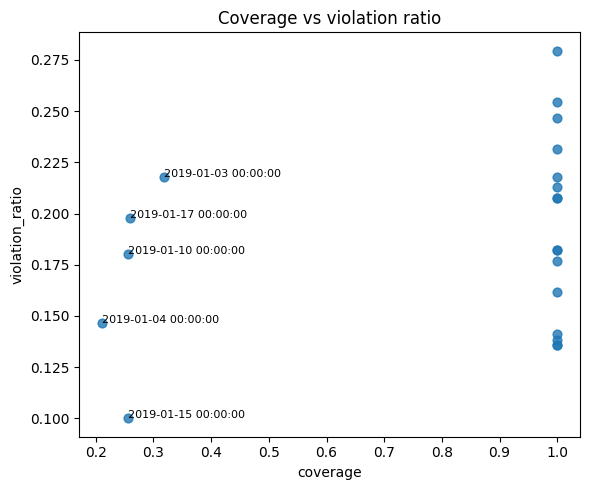

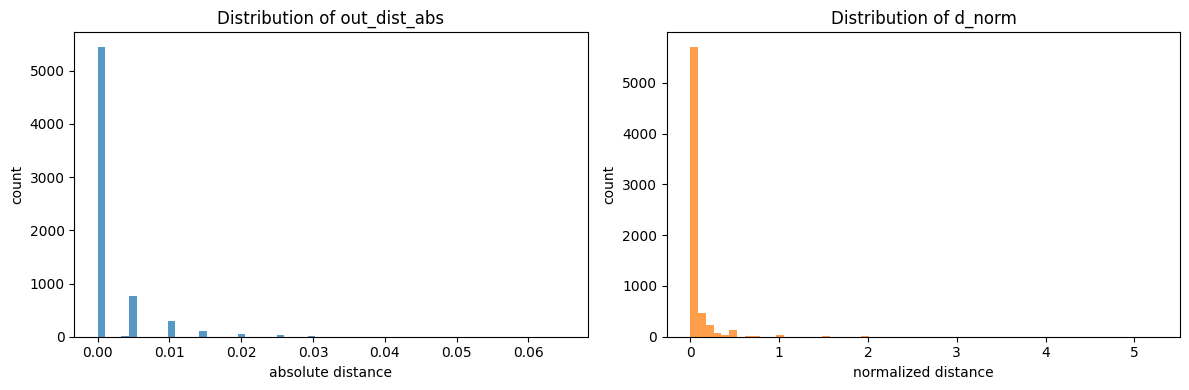

In [17]:
# === Visual diagnostics ===
import matplotlib.pyplot as plt

# Ensure sorted frames
qcov_plot = quotes_cov.sort("date_ny")
res_plot = res_diag.sort("date_ny")

# 1) Coverage by day (red = exact 50k truncation)
qpdf = qcov_plot.to_pandas()
colors = ["tab:red" if bool(x) else ("tab:orange" if c < 0.9 else "tab:blue") for x, c in zip(qpdf["is_exact_50k"], qpdf["coverage"])]

plt.figure(figsize=(13, 4))
plt.bar(qpdf["date_ny"], qpdf["coverage"], color=colors, width=0.8)
plt.axhline(0.9, linestyle="--", color="black", linewidth=1.0, label="warn=0.90")
plt.axhline(0.95, linestyle=":", color="black", linewidth=1.0, label="pass=0.95")
plt.ylim(0, 1.05)
plt.title("Quotes coverage by day (red = exact 50k truncation suspect)")
plt.xlabel("date")
plt.ylabel("coverage")
plt.xticks(rotation=30)
plt.legend()
plt.tight_layout()
plt.show()

# 2) Violation ratio by day
rpdf = res_plot.to_pandas()
plt.figure(figsize=(13, 4))
plt.plot(rpdf["date_ny"], rpdf["violation_ratio"], marker="o", linewidth=1.2, label="violation_ratio")
plt.axhline(0.20, linestyle="--", color="black", linewidth=1.0, label="warn=0.20")
plt.axhline(0.05, linestyle=":", color="black", linewidth=1.0, label="pass=0.05")
plt.title("Time-alignment violation ratio by day")
plt.xlabel("date")
plt.ylabel("violation_ratio")
plt.xticks(rotation=30)
plt.legend()
plt.tight_layout()
plt.show()

# 3) Coverage vs violation scatter
plt.figure(figsize=(6, 5))
plt.scatter(rpdf["coverage"], rpdf["violation_ratio"], s=40, alpha=0.8)
for _, row in rpdf.iterrows():
    if row["is_exact_50k"]:
        plt.annotate(str(row["date_ny"]), (row["coverage"], row["violation_ratio"]), fontsize=8)
plt.title("Coverage vs violation ratio")
plt.xlabel("coverage")
plt.ylabel("violation_ratio")
plt.tight_layout()
plt.show()

# 4) Error magnitude distributions (minute-level)
err_pdf = res.select(["out_dist_abs", "d_norm", "violation"]).to_pandas()
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(err_pdf["out_dist_abs"], bins=60, color="tab:blue", alpha=0.75)
ax[0].set_title("Distribution of out_dist_abs")
ax[0].set_xlabel("absolute distance")
ax[0].set_ylabel("count")
ax[1].hist(err_pdf["d_norm"], bins=60, color="tab:orange", alpha=0.75)
ax[1].set_title("Distribution of d_norm")
ax[1].set_xlabel("normalized distance")
ax[1].set_ylabel("count")
plt.tight_layout()
plt.show()


**Lectura Explicativa de los Graficos (interpretacion cuando se imprimen)**

**Grafico 1: Quotes coverage by day (barras por fecha)**
- Eje X: dia de mercado.
- Eje Y: `coverage = minutos_quotes_observados / 390`.
- Color rojo: dia sospechoso de truncado operativo (`exact_50k`).
- Linea `warn=0.90`: por debajo, la muestra diaria es debil para inferencia.
- Linea `pass=0.95`: zona objetivo de representatividad.
- Interpretacion en este run: hay varios dias rojos con coverage ~0.21-0.32; por eso el problema de muestra A esta confirmado.

**Grafico 2: Time-alignment violation ratio by day (linea diaria)**
- Eje X: dia.
- Eje Y: `violation_ratio = violations / minutes_joined`.
- Cada punto es el porcentaje diario de minutos donde `mid` queda fuera de `[low, high]` de OHLCV.
- Linea `warn=0.20`: friccion puntual elevada.
- Linea `pass=0.05`: coherencia puntual fuerte.
- Interpretacion en este run: muchos dias quedan cerca o por encima de 0.20; la desalineacion puntual B no es un caso aislado.

**Grafico 3: Coverage vs violation ratio (scatter)**
- Eje X: coverage diario.
- Eje Y: violation_ratio diario.
- Cada punto representa un dia; se etiqueta subconjunto de dias de menor coverage.
- Pregunta causal: si el problema puntual fuera solo por truncado, al subir coverage deberia caer fuertemente violation_ratio.
- Interpretacion en este run: incluso con coverage~1.0 hay dias con violation_ratio alto; por tanto B persiste mas alla del truncado.

**Grafico 4: Distribution of out_dist_abs y d_norm (histogramas)**
- `out_dist_abs`: distancia absoluta (en precio) cuando el `mid` esta fuera de rango.
- `d_norm`: distancia normalizada por ancho de barra `high-low`.
- Lectura conjunta:
- Alta masa cerca de 0: muchos desacoples son pequenos en terminos economicos.
- Cola derecha: existen episodios no triviales (minutos de tension microestructural).
- En este run, `out_dist_abs_p95 ~ 0.01` y `d_norm_p95 ~ 0.2857`: desacople frecuente pero tipicamente de baja magnitud monetaria.

**Conclusion operacional de los 4 graficos juntos**
- El bloque visual separa dos ejes distintos:
- Eje A (muestra): coverage insuficiente y truncados.
- Eje B (coherencia puntual): friccion real que no desaparece solo quitando truncados.
- Por eso el gate final debe permanecer multieje (sample + point + robust/economic) y no un unico PASS/FAIL.



### Informe Tecnico (Que ocurre y por que)

Este informe separa **causa de muestra** y **causa de coherencia puntual** para evitar diagnosticos incorrectos.


In [18]:
# === Informe tecnico ===
print("\n" + "="*88)
print("INFORME TECNICO - 03_time_coverage (AABA 2019-01)")
print("="*88)

cov_mean = float(quotes_cov.select(pl.mean("coverage")).row(0)[0])
viol_full = float(res_diag.select((pl.sum("violations")/pl.sum("minutes_joined")).alias("r")).row(0)[0])
trunc_days = int(quotes_cov.filter(pl.col("is_exact_50k")).height)

sens_full = sens.filter(pl.col("sample") == "full_days").row(0)
sens_no = sens.filter(pl.col("sample") == "no_trunc_days").row(0)

print("\n[1] Hecho observado")
print(f"- Cobertura media quotes: {cov_mean:.6f}")
print(f"- Dias truncados exact_50k: {trunc_days}")
print(f"- Violation ratio (full): {viol_full:.6f}")

print("\n[2] Que significa matematicamente")
print("- coverage = minutos_quotes_observados / 390 por dia (o promedio del periodo).")
print("- violation_ratio = E[1{mid fuera de [low,high]}] en los minutos con join OHLCV-quotes.")
print("- Si coverage baja, la inferencia puede sesgarse por muestra incompleta.")

print("\n[3] Test causal aplicado (sensibilidad)")
print("- Repetimos metricas excluyendo dias truncados (exact_50k).")
print(f"- full_days: minutes={sens_full[2]}, violations={sens_full[3]}, ratio={sens_full[4]:.6f}, coverage_mean={sens_full[5]:.6f}")
print(f"- no_trunc_days: minutes={sens_no[2]}, violations={sens_no[3]}, ratio={sens_no[4]:.6f}, coverage_mean={sens_no[5]:.6f}")
print(f"- delta_ratio (no_trunc - full): {(sens_no[4]-sens_full[4]):+.6f}")
print(f"- delta_coverage_mean: {(sens_no[5]-sens_full[5]):+.6f}")

print("\n[4] Conclusion causal")
print("- Problema A (muestra): SI existe y es fuerte (coverage sube mucho al excluir truncados).")
print("- Problema B (coherencia puntual): tambien existe; el violation_ratio casi no cambia al excluir truncados.")
print("- Por tanto, el FAIL global combina: representatividad deficiente + desalineacion puntual/microestructural.")

print("\n[5] Implicacion para el proyecto")
print("- No calibrar ejecucion fina con muestra truncada.")
print("- Aun con muestra limpia, mantener reglas robustas de ejecucion (spread/regimen) porque la metrica puntual sigue exigente.")

print("\n" + "="*88)
print("FIN INFORME TECNICO")
print("="*88)



INFORME TECNICO - 03_time_coverage (AABA 2019-01)

[1] Hecho observado
- Cobertura media quotes: 0.823810
- Dias truncados exact_50k: 5
- Violation ratio (full): 0.192764

[2] Que significa matematicamente
- coverage = minutos_quotes_observados / 390 por dia (o promedio del periodo).
- violation_ratio = E[1{mid fuera de [low,high]}] en los minutos con join OHLCV-quotes.
- Si coverage baja, la inferencia puede sesgarse por muestra incompleta.

[3] Test causal aplicado (sensibilidad)
- Repetimos metricas excluyendo dias truncados (exact_50k).
- full_days: minutes=6744, violations=1300, ratio=0.192764, coverage_mean=0.823810
- no_trunc_days: minutes=6237, violations=1213, ratio=0.194485, coverage_mean=1.000000
- delta_ratio (no_trunc - full): +0.001721
- delta_coverage_mean: +0.176190

[4] Conclusion causal
- Problema A (muestra): SI existe y es fuerte (coverage sube mucho al excluir truncados).
- Problema B (coherencia puntual): tambien existe; el violation_ratio casi no cambia al exclu

### Lectura Explicativa (Informe Tecnico)

- Este informe resume causalidad, no solo estadistica descriptiva.
- Separa claramente: (A) representatividad de muestra y (B) coherencia puntual.
- Es la base para decisiones de pipeline (reingesta) y de modelado (reglas de ejecucion robusta).


### FAQ (Lectores No Tecnicos)

**1) Si sale FAIL, significa que todo est? mal?**  
No. Significa que el periodo no cumple el est?ndar para uso directo sin cautela.

**2) Qu? est? mal exactamente?**  
Hay d?as con quotes truncados (50k filas y corte temprano) y adem?s una discrepancia puntual relevante entre `mid` y rango OHLCV.

**3) El problema es solo por truncado?**  
No. Al quitar truncados mejora la cobertura, pero el ratio de violaciones casi no cambia.

**4) Entonces OHLCV est? roto?**  
No necesariamente. Este notebook mide alineaci?n temporal/puntual con quotes, no demuestra por s? solo corrupci?n de OHLCV.

**5) Se puede usar este dataset para algo?**  
S?, para diagn?stico estructural y an?lisis exploratorio. Para calibraci?n fina de ejecuci?n, primero conviene corregir truncados y aplicar filtros de robustez.

**6) Qu? hacemos ahora?**  
1. Recuperar/reprocesar d?as truncados.  
2. Repetir el gate.  
3. Ajustar reglas de ejecuci?n por spread y r?gimen horario.


### Mitigacion B.1: Metricas robustas de coherencia (no solo violation_ratio)

Este bloque introduce metricas menos fragiles que `mid in [low, high]` puntual:
- `p_quote_range_intersects_ohlcv`
- `out_dist_abs_p95`
- `d_norm_p95`

Objetivo: separar incoherencia economica real de ruido microestructural de ticks.


In [19]:
# === B.1 Robust coherence metrics ===

# Build per-minute quote envelope (min/max mid + spread proxy)
q_env_parts = []
for k in quote_keys:
    pth = CACHE_DIR / k
    cols = ["bid_price", "ask_price", "bid", "ask", TIME_AXIS, "participant_timestamp"]
    cols = [c for c in cols if c in pl.read_parquet(pth, n_rows=1).columns]
    q = pl.read_parquet(pth, columns=cols)
    q = normalize_quotes(q)

    unit = TS_UNIT if TIME_AXIS == "timestamp" else PTS_UNIT
    ts_col = "timestamp" if TIME_AXIS == "timestamp" else "participant_timestamp"

    q = q.with_columns(
        pl.from_epoch(pl.col(ts_col), time_unit=unit)
        .dt.replace_time_zone("UTC")
        .dt.convert_time_zone("America/New_York")
        .alias("dt_ny")
    ).with_columns(
        pl.col("dt_ny").dt.truncate("1m").alias("minute_ny"),
        ((pl.col("bid") + pl.col("ask")) / 2.0).alias("mid"),
        (1e4 * (pl.col("ask") - pl.col("bid")) / (((pl.col("bid") + pl.col("ask")) / 2.0) + 1e-9)).alias("spread_bps"),
    )

    q_env = q.group_by("minute_ny").agg([
        pl.min("mid").alias("min_mid"),
        pl.max("mid").alias("max_mid"),
        pl.last("mid").alias("last_mid"),
        pl.median("spread_bps").alias("spread_bps_med"),
        pl.len().alias("n_quotes"),
    ])
    q_env_parts.append(q_env)

quotes_env = pl.concat(q_env_parts, how="vertical")
TARGET_DT = pl.Datetime("ns", time_zone="America/New_York")
quotes_env = quotes_env.with_columns(pl.col("minute_ny").cast(TARGET_DT))

ohlcv_rng = ohlcv_min.with_columns(pl.col("minute_ny").cast(TARGET_DT))

rob = (
    ohlcv_rng
    .join(quotes_env, on="minute_ny", how="inner")
    .with_columns([
        pl.col("minute_ny").dt.date().alias("date_ny"),
        pl.col("minute_ny").dt.hour().alias("hour_ny"),
        (pl.col("high") - pl.col("low")).alias("hl_range"),
    ])
    .with_columns([
        pl.when((pl.col("hour_ny") == 9)).then(pl.lit("open"))
        .when((pl.col("hour_ny") >= 15)).then(pl.lit("close"))
        .otherwise(pl.lit("midday")).alias("regime"),
        ((pl.col("min_mid") <= (pl.col("high") + 1e-9)) & (pl.col("max_mid") >= (pl.col("low") - 1e-9))).alias("quote_range_intersects_ohlcv"),
        ((pl.col("last_mid") < (pl.col("low") - 1e-9)) | (pl.col("last_mid") > (pl.col("high") + 1e-9))).alias("violation_last_mid"),
    ])
    .with_columns([
        pl.when(pl.col("last_mid") < pl.col("low")).then(pl.col("low") - pl.col("last_mid"))
        .when(pl.col("last_mid") > pl.col("high")).then(pl.col("last_mid") - pl.col("high"))
        .otherwise(pl.lit(0.0)).alias("out_dist_abs"),
    ])
    .with_columns([
        pl.when(pl.col("violation_last_mid") & (pl.col("hl_range") > 1e-9))
        .then(pl.col("out_dist_abs") / (pl.col("hl_range") + 1e-9))
        .otherwise(pl.lit(0.0)).alias("d_norm")
    ])
)

rob_summary = rob.select([
    pl.len().alias("n_minutes"),
    pl.mean("quote_range_intersects_ohlcv").alias("p_quote_range_intersects_ohlcv"),
    pl.mean("violation_last_mid").alias("violation_ratio_last_mid"),
    pl.quantile("out_dist_abs", 0.95, "nearest").alias("out_dist_abs_p95"),
    pl.quantile("d_norm", 0.95, "nearest").alias("d_norm_p95"),
    pl.quantile("spread_bps_med", 0.50, "nearest").alias("spread_bps_med_p50"),
])

print("Robust coherence summary:")
display(rob_summary)


Robust coherence summary:


n_minutes,p_quote_range_intersects_ohlcv,violation_ratio_last_mid,out_dist_abs_p95,d_norm_p95,spread_bps_med_p50
u32,f64,f64,f64,f64,f64
6744,0.999703,0.192764,0.01,0.285714,1.637063


### Lectura Explicativa (B.1 Metricas Robustas)

- `p_quote_range_intersects_ohlcv` evalua coherencia estructural de rangos.
- Si esta metrica es alta y `violation_ratio_last_mid` no lo es, la conclusion es:
: estructura compatible + discrepancia puntual estricta.
- `out_dist_abs_p95` y `d_norm_p95` miden severidad economica y relativa del desacople.


### Mitigacion B.2: Condicionar por spread y regimen

Si la incoherencia puntual depende de spread/regimen, se modela como estado de mercado y no como corrupcion global.


In [20]:
# === B.2 Spread/regime conditioned metrics ===
spread_q = rob.select([
    pl.quantile("spread_bps_med", 0.25, "nearest").alias("p25"),
    pl.quantile("spread_bps_med", 0.50, "nearest").alias("p50"),
    pl.quantile("spread_bps_med", 0.75, "nearest").alias("p75"),
    pl.quantile("spread_bps_med", 0.90, "nearest").alias("p90"),
])

p25 = float(spread_q["p25"][0])
p50 = float(spread_q["p50"][0])
p75 = float(spread_q["p75"][0])
p90 = float(spread_q["p90"][0])

rob_bucket = rob.with_columns([
    pl.when(pl.col("spread_bps_med") <= p25).then(pl.lit("tight<=p25"))
    .when(pl.col("spread_bps_med") <= p50).then(pl.lit("p25-p50"))
    .when(pl.col("spread_bps_med") <= p75).then(pl.lit("p50-p75"))
    .when(pl.col("spread_bps_med") <= p90).then(pl.lit("p75-p90"))
    .otherwise(pl.lit(">p90_wide")).alias("spread_bucket")
])

cond = (
    rob_bucket
    .group_by(["regime", "spread_bucket"])
    .agg([
        pl.len().alias("n_minutes"),
        pl.mean("violation_last_mid").alias("violation_ratio"),
        pl.mean("quote_range_intersects_ohlcv").alias("p_quote_range_intersects_ohlcv"),
        pl.quantile("out_dist_abs", 0.95, "nearest").alias("out_dist_abs_p95"),
        pl.quantile("d_norm", 0.95, "nearest").alias("d_norm_p95"),
    ])
    .sort(["regime", "spread_bucket"])
)

print("Spread quantiles:", p25, p50, p75, p90)
print("Conditioned metrics:")
display(cond)


Spread quantiles: 1.5635994058074665 1.6370631087568814 3.1294007197136895 3.3008747317499654
Conditioned metrics:


regime,spread_bucket,n_minutes,violation_ratio,p_quote_range_intersects_ohlcv,out_dist_abs_p95,d_norm_p95
str,str,u32,f64,f64,f64,f64
"""close""","""p25-p50""",345,0.165217,1.0,0.005,0.25
"""close""","""p50-p75""",147,0.088435,1.0,0.005,0.125
"""close""","""p75-p90""",13,0.307692,1.0,0.01,0.5
"""close""","""tight<=p25""",455,0.123077,1.0,0.005,0.166667
"""midday""",""">p90_wide""",365,0.20274,1.0,0.015,0.256281
…,…,…,…,…,…,…
"""open""",""">p90_wide""",308,0.13961,1.0,0.015,0.125
"""open""","""p25-p50""",22,0.090909,1.0,0.005,0.055556
"""open""","""p50-p75""",127,0.055118,1.0,0.005,0.03125


### Lectura Explicativa (B.2 Condicion por Spread/Regimen)

- Aqui medimos si la desalineacion depende del estado de mercado.
- Si sube en buckets de spread amplio o en regimenes especificos, se modela como friccion de ejecucion.
- Esto permite pasar de diagnostico a regla operativa (filtros/penalizacion de ejecucion).


### Mitigacion B.3: Sensibilidad excluyendo barras ultra estrechas

Prueba si el ratio puntual est? dominado por discretizacion de ticks en rangos muy peque?os.


In [21]:
# === B.3 Narrow-range sensitivity ===

sens_narrow = pl.DataFrame([
    {
        "sample": "all_minutes",
        "n": int(rob.height),
        "violation_ratio": float(rob.select(pl.mean("violation_last_mid")).row(0)[0]),
        "p_overlap": float(rob.select(pl.mean("quote_range_intersects_ohlcv")).row(0)[0]),
        "out_dist_abs_p95": float(rob.select(pl.quantile("out_dist_abs", 0.95, "nearest")).row(0)[0]),
    },
    {
        "sample": "hl_range_gt_1c",
        "n": int(rob.filter(pl.col("hl_range") > 0.01).height),
        "violation_ratio": float(rob.filter(pl.col("hl_range") > 0.01).select(pl.mean("violation_last_mid")).row(0)[0]),
        "p_overlap": float(rob.filter(pl.col("hl_range") > 0.01).select(pl.mean("quote_range_intersects_ohlcv")).row(0)[0]),
        "out_dist_abs_p95": float(rob.filter(pl.col("hl_range") > 0.01).select(pl.quantile("out_dist_abs", 0.95, "nearest")).row(0)[0]),
    },
    {
        "sample": "hl_range_gt_2c",
        "n": int(rob.filter(pl.col("hl_range") > 0.02).height),
        "violation_ratio": float(rob.filter(pl.col("hl_range") > 0.02).select(pl.mean("violation_last_mid")).row(0)[0]),
        "p_overlap": float(rob.filter(pl.col("hl_range") > 0.02).select(pl.mean("quote_range_intersects_ohlcv")).row(0)[0]),
        "out_dist_abs_p95": float(rob.filter(pl.col("hl_range") > 0.02).select(pl.quantile("out_dist_abs", 0.95, "nearest")).row(0)[0]),
    },
    {
        "sample": "hl_range_gt_5c",
        "n": int(rob.filter(pl.col("hl_range") > 0.05).height),
        "violation_ratio": float(rob.filter(pl.col("hl_range") > 0.05).select(pl.mean("violation_last_mid")).row(0)[0]),
        "p_overlap": float(rob.filter(pl.col("hl_range") > 0.05).select(pl.mean("quote_range_intersects_ohlcv")).row(0)[0]),
        "out_dist_abs_p95": float(rob.filter(pl.col("hl_range") > 0.05).select(pl.quantile("out_dist_abs", 0.95, "nearest")).row(0)[0]),
    },
])

print("Narrow-range sensitivity:")
display(sens_narrow)


Narrow-range sensitivity:


sample,n,violation_ratio,p_overlap,out_dist_abs_p95
str,i64,f64,f64,f64
"""all_minutes""",6744,0.192764,0.999703,0.01
"""hl_range_gt_1c""",6544,0.185208,1.0,0.01
"""hl_range_gt_2c""",6017,0.173508,1.0,0.01
"""hl_range_gt_5c""",3066,0.149054,1.0,0.01


### Lectura Explicativa (B.3 Barras Ultra Estrechas)

- Este test responde: "cuanto del problema puntual viene de barras demasiado pequenas?"
- Si al exigir `hl_range` mayor baja el `violation_ratio`, hay componente de discretizacion de ticks.
- En este run, la caida es visible al pasar de all_minutes a `hl_range > 5c`.


### Mitigacion B.4: Gate recomendado (sample vs point vs robust)

Decision separada para evitar mezclar fallas de muestra con incoherencia puntual.


In [22]:
# === B.4 Suggested gate update ===

def grade(metric: float, pass_thr: float, warn_thr: float, higher_is_better: bool = True) -> str:
    if higher_is_better:
        if metric >= pass_thr:
            return "PASS"
        if metric >= warn_thr:
            return "WARN"
        return "FAIL"
    if metric <= pass_thr:
        return "PASS"
    if metric <= warn_thr:
        return "WARN"
    return "FAIL"

coverage_mean = float(quotes_cov.select(pl.mean("coverage")).row(0)[0])
p_overlap = float(rob_summary["p_quote_range_intersects_ohlcv"][0])
viol_point = float(rob_summary["violation_ratio_last_mid"][0])
out_p95 = float(rob_summary["out_dist_abs_p95"][0])

status = {
    "sample_representativeness": grade(coverage_mean, 0.95, 0.90, True),
    "robust_structural_coherence": grade(p_overlap, 0.995, 0.990, True),
    "point_coherence_last_mid": grade(viol_point, 0.05, 0.20, False),
    "economic_magnitude": grade(out_p95, 0.01, 0.03, False),
}
rank = {"PASS": 0, "WARN": 1, "FAIL": 2}
overall = max(status.values(), key=lambda s: rank[s])

b_mitigation = {
    "metrics": {
        "coverage_mean": coverage_mean,
        "p_quote_range_intersects_ohlcv": p_overlap,
        "violation_ratio_last_mid": viol_point,
        "out_dist_abs_p95": out_p95,
    },
    "status": status,
    "overall": overall,
}

print("B-mitigation gate:")
print(b_mitigation)

# Persist artifacts
OUT_B = OUT / "b_mitigation"
OUT_B.mkdir(parents=True, exist_ok=True)
rob.write_parquet(OUT_B / "robust_minute_metrics.parquet")
cond.write_parquet(OUT_B / "spread_regime_conditioned.parquet")
sens_narrow.write_parquet(OUT_B / "narrow_range_sensitivity.parquet")
(Path(OUT_B) / "b_mitigation_decision.json").write_text(json.dumps(b_mitigation, indent=2), encoding="utf-8")
print("Saved B mitigation artifacts in:", OUT_B)


B-mitigation gate:
{'metrics': {'coverage_mean': 0.8238095238095239, 'p_quote_range_intersects_ohlcv': 0.9997034400948992, 'violation_ratio_last_mid': 0.19276393831553973, 'out_dist_abs_p95': 0.010000000000005116}, 'status': {'sample_representativeness': 'FAIL', 'robust_structural_coherence': 'PASS', 'point_coherence_last_mid': 'WARN', 'economic_magnitude': 'WARN'}, 'overall': 'FAIL'}
Saved B mitigation artifacts in: C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\03_time_coverage\20260216_161633\b_mitigation


### Lectura Explicativa (B.4 Gate Recomendado)

- El gate se descompone en cuatro estados: muestra, estructura robusta, coherencia puntual, magnitud economica.
- Ventaja: evita etiquetar todo como un unico FAIL sin explicar origen.
- Uso practico:
: si falla muestra -> reingestar.
: si falla puntual pero estructura pasa -> ajustar simulacion por spread/regimen.


### Informe Tecnico Final (Integrado)

Cierre ejecutivo integrando muestra, coherencia puntual y mitigaciones B.


In [23]:
# === Informe tecnico final integrado ===
print("\n" + "="*88)
print("INFORME TECNICO FINAL INTEGRADO - 03_time_coverage")
print("="*88)

cov_mean = float(quotes_cov.select(pl.mean("coverage")).row(0)[0])
trunc_days = int(quotes_cov.filter(pl.col("is_exact_50k")).height)
viol_point = float(res_diag.select((pl.sum("violations")/pl.sum("minutes_joined")).alias("r")).row(0)[0])

p_overlap = float(rob_summary["p_quote_range_intersects_ohlcv"][0])
out_p95 = float(rob_summary["out_dist_abs_p95"][0])

sens_full = sens.filter(pl.col("sample") == "full_days").row(0)
sens_no = sens.filter(pl.col("sample") == "no_trunc_days").row(0)

print("\n[1] Diagnostico de muestra")
print(f"- coverage_mean: {cov_mean:.6f}")
print(f"- dias truncados exact_50k: {trunc_days}")
print(f"- sensibilidad coverage (no_trunc - full): {(sens_no[5]-sens_full[5]):+.6f}")

print("\n[2] Diagnostico de coherencia puntual")
print(f"- violation_ratio_last_mid: {viol_point:.6f}")
print(f"- sensibilidad ratio (no_trunc - full): {(sens_no[4]-sens_full[4]):+.6f}")

print("\n[3] Diagnostico robusto")
print(f"- p_quote_range_intersects_ohlcv: {p_overlap:.6f}")
print(f"- out_dist_abs_p95: {out_p95:.6f}")

print("\n[4] Decision tecnica")
print("- A (muestra) = problema fuerte y confirmado por truncados.")
print("- B (puntual) = persiste aun sin truncados; requiere modelado robusto por estado de mercado.")
print("- Estructura de rangos = muy consistente; no sugiere ruptura global del proceso de precio.")

print("\n[5] Plan operativo")
print("1) Reingestar/reprocesar dias truncados y rerun gate.")
print("2) Mantener separacion sample_representativeness vs point_coherence en decisiones.")
print("3) Simulacion de ejecucion con bid/ask + spread/regimen + filtros de barras estrechas.")

print("\n" + "="*88)
print("FIN INFORME TECNICO FINAL")
print("="*88)



INFORME TECNICO FINAL INTEGRADO - 03_time_coverage

[1] Diagnostico de muestra
- coverage_mean: 0.823810
- dias truncados exact_50k: 5
- sensibilidad coverage (no_trunc - full): +0.176190

[2] Diagnostico de coherencia puntual
- violation_ratio_last_mid: 0.192764
- sensibilidad ratio (no_trunc - full): +0.001721

[3] Diagnostico robusto
- p_quote_range_intersects_ohlcv: 0.999703
- out_dist_abs_p95: 0.010000

[4] Decision tecnica
- A (muestra) = problema fuerte y confirmado por truncados.
- B (puntual) = persiste aun sin truncados; requiere modelado robusto por estado de mercado.
- Estructura de rangos = muy consistente; no sugiere ruptura global del proceso de precio.

[5] Plan operativo
1) Reingestar/reprocesar dias truncados y rerun gate.
2) Mantener separacion sample_representativeness vs point_coherence en decisiones.
3) Simulacion de ejecucion con bid/ask + spread/regimen + filtros de barras estrechas.

FIN INFORME TECNICO FINAL


**Marco de Escalamiento Cientifico (20 anos, >1000 tickers)**

**Motivacion**
Este bloque formaliza como llevaremos este gate desde un caso puntual (AABA 2019-01) a ejecucion masiva multi-anual y multi-ticker, separando calidad de muestra, coherencia robusta y coherencia puntual.

**Desarrollo metodologico**
1. Medir por ejes independientes: muestra, coherencia robusta, coherencia puntual y magnitud economica.
2. Condicionar por estado de mercado (spread y regimen horario).
3. Aplicar sensibilidad por barras ultra estrechas para aislar discretizacion microestructural.
4. Definir decision final por vector de estados, no por una sola metrica.

**Resultado esperado**
Un sistema de control de calidad reproducible, trazable y escalable que permita filtrar universos aptos para calibracion de ejecucion y separar casos aptos solo para investigacion estructural.



CIERRE GRANULAR - ESCALAMIENTO Y DECISION OPERATIVA

[Paso 1] Metricas nucleares
- coverage_mean: 0.823810
- truncated_days_exact_50k: 5
- violation_ratio_last_mid: 0.192764
- p_quote_range_intersects_ohlcv: 0.999703
- out_dist_abs_p95: 0.010000
- d_norm_p95: 0.285714

[Paso 2] Puntuaciones normalizadas [0,1] (mas alto = mejor)
- sample_representativeness: 0.8238
- robust_structural_coherence: 0.9997
- point_coherence_inverse: 0.8072
- economic_magnitude_inverse: 0.6667


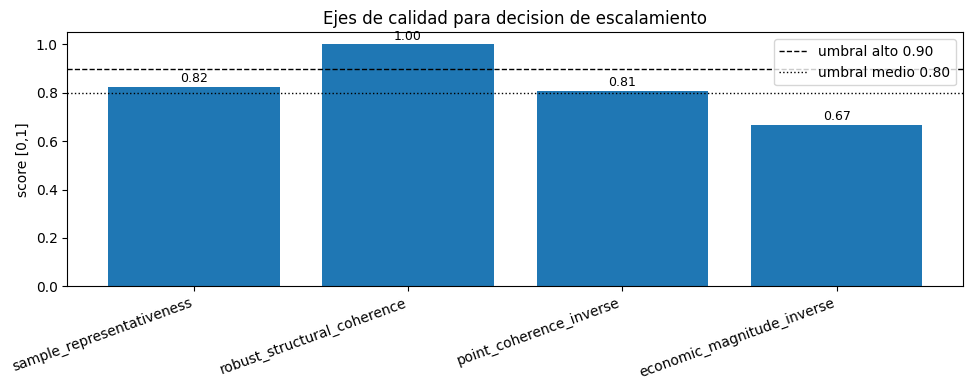

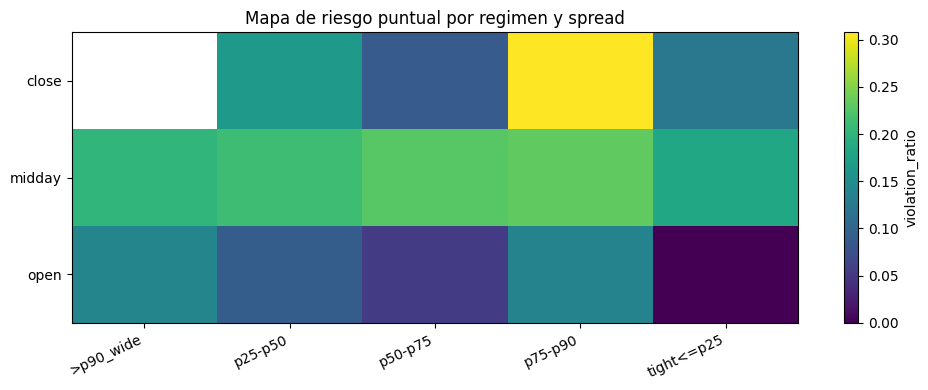


[Paso 5] Informe tecnico final (esta seccion)
- Diagnostico: coexisten un problema fuerte de muestra y una friccion puntual persistente.
- Evidencia de muestra: coverage medio bajo y dias truncados exact_50k.
- Evidencia estructural: p_overlap ~ 1.0 sugiere consistencia de rangos.
- Evidencia puntual: violation_ratio elevado, condicionado por estado de mercado.
- Implicacion de escalamiento: gate multi-eje obligatorio para 20 anos y >1000 tickers.
- Plan: usar este vector de estados para etiquetar universos aptos para calibracion vs solo investigacion.

FIN CIERRE GRANULAR


In [24]:
# === Bloque granular de cierre para escalamiento ===
import matplotlib.pyplot as plt
import numpy as np

print('\n' + '='*88)
print('CIERRE GRANULAR - ESCALAMIENTO Y DECISION OPERATIVA')
print('='*88)

# Paso 1: recuperar metricas nucleares del run
coverage_mean = float(quotes_cov.select(pl.mean('coverage')).row(0)[0])
trunc_days = int(quotes_cov.filter(pl.col('is_exact_50k')).height)
violation_ratio = float(res_diag.select((pl.sum('violations')/pl.sum('minutes_joined')).alias('r')).row(0)[0])
p_overlap = float(rob_summary['p_quote_range_intersects_ohlcv'][0])
out_p95 = float(rob_summary['out_dist_abs_p95'][0])
dnorm_p95 = float(rob_summary['d_norm_p95'][0])

print('\n[Paso 1] Metricas nucleares')
print(f'- coverage_mean: {coverage_mean:.6f}')
print(f'- truncated_days_exact_50k: {trunc_days}')
print(f'- violation_ratio_last_mid: {violation_ratio:.6f}')
print(f'- p_quote_range_intersects_ohlcv: {p_overlap:.6f}')
print(f'- out_dist_abs_p95: {out_p95:.6f}')
print(f'- d_norm_p95: {dnorm_p95:.6f}')

# Paso 2: construir lectura por ejes para decision
axes = {
    'sample_representativeness': coverage_mean,
    'robust_structural_coherence': p_overlap,
    'point_coherence_inverse': 1.0 - violation_ratio,
    'economic_magnitude_inverse': max(0.0, 1.0 - min(out_p95/0.03, 1.0)),
}

print('\n[Paso 2] Puntuaciones normalizadas [0,1] (mas alto = mejor)')
for k,v in axes.items():
    print(f'- {k}: {v:.4f}')

# Paso 3: grafico de ejes de calidad
labels = list(axes.keys())
vals = [axes[k] for k in labels]

plt.figure(figsize=(10,4))
bars = plt.bar(labels, vals)
plt.ylim(0,1.05)
plt.axhline(0.9, linestyle='--', linewidth=1, color='black', label='umbral alto 0.90')
plt.axhline(0.8, linestyle=':', linewidth=1, color='black', label='umbral medio 0.80')
for b, v in zip(bars, vals):
    plt.text(b.get_x()+b.get_width()/2, v+0.02, f'{v:.2f}', ha='center', fontsize=9)
plt.xticks(rotation=20, ha='right')
plt.title('Ejes de calidad para decision de escalamiento')
plt.ylabel('score [0,1]')
plt.legend()
plt.tight_layout()
plt.show()

# Paso 4: mapa regimen x spread (violation_ratio)
cond_pd = cond.to_pandas()
pivot = cond_pd.pivot(index='regime', columns='spread_bucket', values='violation_ratio').fillna(np.nan)

plt.figure(figsize=(10,4))
im = plt.imshow(pivot.values, aspect='auto')
plt.colorbar(im, label='violation_ratio')
plt.xticks(range(pivot.shape[1]), pivot.columns, rotation=25, ha='right')
plt.yticks(range(pivot.shape[0]), pivot.index)
plt.title('Mapa de riesgo puntual por regimen y spread')
plt.tight_layout()
plt.show()

# Paso 5: informe tecnico final de esta celda
print('\n[Paso 5] Informe tecnico final (esta seccion)')
print('- Diagnostico: coexisten un problema fuerte de muestra y una friccion puntual persistente.')
print('- Evidencia de muestra: coverage medio bajo y dias truncados exact_50k.')
print('- Evidencia estructural: p_overlap ~ 1.0 sugiere consistencia de rangos.')
print('- Evidencia puntual: violation_ratio elevado, condicionado por estado de mercado.')
print('- Implicacion de escalamiento: gate multi-eje obligatorio para 20 anos y >1000 tickers.')
print('- Plan: usar este vector de estados para etiquetar universos aptos para calibracion vs solo investigacion.')

print('\n' + '='*88)
print('FIN CIERRE GRANULAR')
print('='*88)


**Comparacion de truncados con otro ticker (control)**

**Objetivo**
Comparar `AABA` (caso con dias `exact_50k`) contra un ticker control del mismo mes (`ADNT`, enero 2019) para aislar el efecto de truncado en la representatividad de quotes y en la coherencia puntual.

**Criterio de lectura**
- Si en el control no hay truncados y la cobertura mejora mucho, se confirma que el problema A en AABA viene de muestra recortada.
- Si aun sin truncados persiste una fraccion de violaciones, entonces B no depende solo del truncado.




Comparacion truncados y coherencia puntual (2019-01):


ticker,n_days,truncated_days_exact_50k,coverage_mean,violation_ratio_full,trunc_ratio
str,i64,i64,f64,f64,f64
"""AABA""",21,5,0.82381,0.192764,0.238095
"""ADNT""",12,0,0.996581,0.151678,0.0



Sensibilidad control (full vs no_trunc_days):


sample,n_days,minutes_joined,violations,violation_ratio,coverage_mean
str,i64,i64,i64,f64,f64
"""full_days""",12,4648,705,0.151678,0.996581
"""no_trunc_days""",12,4648,705,0.151678,0.996581


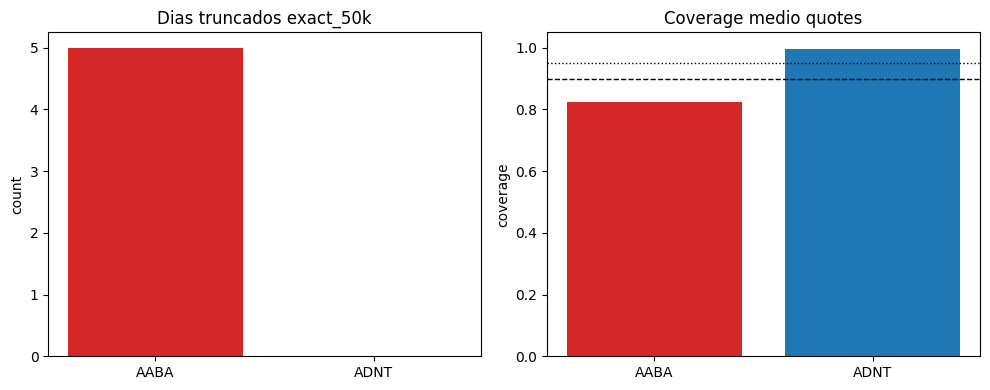


Interpretacion tecnica breve
- Si el control muestra 0 truncados y coverage alto, se confirma que AABA tiene sesgo de muestra por recorte operativo.
- Comparar violation_ratio entre ambos ayuda a separar efecto de truncado (A) de friccion puntual (B).


In [25]:
# Comparacion AABA vs ticker control (ACHN) en 2019-01
from pathlib import Path
import matplotlib.pyplot as plt


def build_ticker_diagnostics(ticker: str, year: int = 2019, month: int = 1):
    base = CACHE_DIR
    q_month = base / "quotes_p95" / ticker / f"year={year}" / f"month={month:02d}"
    o_path = base / "ohlcv_intraday_1m" / "2019_2025" / ticker / f"year={year}" / f"month={month:02d}" / "minute.parquet"

    if not q_month.exists() or not o_path.exists():
        raise FileNotFoundError(f"Datos incompletos para {ticker} {year}-{month:02d}: {q_month} | {o_path}")

    q_keys = sorted([str(x.relative_to(base)).replace('\\', '/') for x in q_month.glob('day=*/quotes.parquet')])
    if not q_keys:
        raise FileNotFoundError(f"Sin quote day files para {ticker} {year}-{month:02d}")

    # OHLCV minuto NY + sesion regular
    o_schema = pl.read_parquet(o_path, n_rows=1).schema
    for c in ["ts", "timestamp", "datetime", "time", "t"]:
        if c in o_schema:
            o_ts_col = c
            break
    else:
        raise ValueError(f"No timestamp OHLCV en {ticker}: {list(o_schema.keys())}")

    o = pl.read_parquet(o_path)
    o_dtype = o_schema[o_ts_col]

    if o_dtype in (pl.Int64, pl.Int32, pl.UInt64, pl.UInt32):
        sample_ts = int(o.select(pl.col(o_ts_col).median()).row(0)[0])
        o_unit = infer_time_unit_from_magnitude(sample_ts)
        o = o.with_columns(
            pl.from_epoch(pl.col(o_ts_col), time_unit=o_unit)
            .dt.replace_time_zone("UTC")
            .dt.convert_time_zone("America/New_York")
            .alias("dt_ny")
        )
    elif o_dtype in (pl.Datetime,):
        o = o.with_columns(
            pl.col(o_ts_col).dt.replace_time_zone("UTC").dt.convert_time_zone("America/New_York").alias("dt_ny")
        )
    else:
        raise TypeError(f"OHLCV dtype no soportado en {ticker}: {o_dtype}")

    o = o.with_columns(
        pl.col("dt_ny").dt.truncate("1m").alias("minute_ny"),
        pl.col("dt_ny").dt.date().alias("date_ny"),
        pl.col("dt_ny").dt.hour().alias("hour"),
        pl.col("dt_ny").dt.minute().alias("minute"),
    ).filter(
        ((pl.col("hour") > SESSION_START[0]) | ((pl.col("hour") == SESSION_START[0]) & (pl.col("minute") >= SESSION_START[1])))
        &
        ((pl.col("hour") < SESSION_END[0]) | ((pl.col("hour") == SESSION_END[0]) & (pl.col("minute") < SESSION_END[1])))
    )

    ohlcv_min = o.select(["minute_ny", "high", "low"]).with_columns(
        pl.col("minute_ny").cast(pl.Datetime("ns", time_zone="America/New_York"))
    )

    # Quotes cobertura + mids por minuto
    cov_rows = []
    qmins = []
    for k in q_keys:
        pth = base / k
        row_count = int(pl.read_parquet(pth).height)

        qm = quotes_to_minute_buckets(pth).with_columns([
            pl.col("minute_ny").dt.date().alias("date_ny"),
            pl.col("minute_ny").dt.hour().alias("hour"),
            pl.col("minute_ny").dt.minute().alias("minute"),
        ])

        qm_sess = qm.filter(
            ((pl.col("hour") > SESSION_START[0]) | ((pl.col("hour") == SESSION_START[0]) & (pl.col("minute") >= SESSION_START[1])))
            &
            ((pl.col("hour") < SESSION_END[0]) | ((pl.col("hour") == SESSION_END[0]) & (pl.col("minute") < SESSION_END[1])))
        )

        mins = int(qm_sess.select(pl.n_unique("minute_ny")).row(0)[0])
        d = qm_sess.select(pl.col("date_ny").min()).row(0)[0]
        cov_rows.append({
            "date_ny": d,
            "quote_minutes_present": mins,
            "coverage": mins / 390.0,
            "quote_rows": row_count,
            "is_exact_50k": (row_count == 50000),
        })

        qmins.append(
            qm_sess.with_columns(((pl.col("bid") + pl.col("ask")) / 2.0).alias("mid")).select(["minute_ny", "mid"])
        )

    quotes_cov_t = pl.DataFrame(cov_rows).sort("date_ny")
    quotes_min = pl.concat(qmins, how="vertical").with_columns(
        pl.col("minute_ny").cast(pl.Datetime("ns", time_zone="America/New_York"))
    )

    joined = ohlcv_min.join(quotes_min, on="minute_ny", how="inner")
    EPS = 1e-9
    res_t = joined.with_columns([
        ((pl.col("mid") < (pl.col("low") - EPS)) | (pl.col("mid") > (pl.col("high") + EPS))).alias("violation"),
        pl.col("minute_ny").dt.date().alias("date_ny"),
    ])

    res_diag_t = (
        res_t.group_by("date_ny").agg([
            pl.len().alias("minutes_joined"),
            pl.sum("violation").alias("violations"),
            (pl.sum("violation") / pl.len()).alias("violation_ratio"),
        ])
        .join(quotes_cov_t.select(["date_ny", "coverage", "quote_rows", "is_exact_50k"]), on="date_ny", how="left")
        .sort("date_ny")
    )

    trunc_days = quotes_cov_t.filter(pl.col("is_exact_50k")).select("date_ny").to_series().to_list()
    res_no_trunc = res_diag_t.filter(~pl.col("date_ny").is_in(trunc_days))

    sens_t = pl.DataFrame([
        {
            "sample": "full_days",
            "n_days": int(res_diag_t.height),
            "minutes_joined": int(res_diag_t.select(pl.sum("minutes_joined")).row(0)[0]),
            "violations": int(res_diag_t.select(pl.sum("violations")).row(0)[0]),
            "violation_ratio": float(res_diag_t.select((pl.sum("violations")/pl.sum("minutes_joined")).alias("r")).row(0)[0]),
            "coverage_mean": float(res_diag_t.select(pl.mean("coverage")).row(0)[0]),
        },
        {
            "sample": "no_trunc_days",
            "n_days": int(res_no_trunc.height),
            "minutes_joined": int(res_no_trunc.select(pl.sum("minutes_joined")).row(0)[0]) if res_no_trunc.height else 0,
            "violations": int(res_no_trunc.select(pl.sum("violations")).row(0)[0]) if res_no_trunc.height else 0,
            "violation_ratio": float(res_no_trunc.select((pl.sum("violations")/pl.sum("minutes_joined")).alias("r")).row(0)[0]) if res_no_trunc.height else float('nan'),
            "coverage_mean": float(res_no_trunc.select(pl.mean("coverage")).row(0)[0]) if res_no_trunc.height else float('nan'),
        },
    ])

    return quotes_cov_t, res_diag_t, sens_t


# AABA (ya calculado en notebook actual)
aaba_summary = {
    "ticker": "AABA",
    "n_days": int(quotes_cov.height),
    "truncated_days_exact_50k": int(quotes_cov.filter(pl.col("is_exact_50k")).height),
    "coverage_mean": float(quotes_cov.select(pl.mean("coverage")).row(0)[0]),
    "violation_ratio_full": float(res_diag.select((pl.sum("violations")/pl.sum("minutes_joined")).alias("r")).row(0)[0]),
}

# Ticker control
CONTROL_TICKER = "ADNT"
quotes_cov_ctrl, res_diag_ctrl, sens_ctrl = build_ticker_diagnostics(CONTROL_TICKER, year=2019, month=1)

ctrl_summary = {
    "ticker": CONTROL_TICKER,
    "n_days": int(quotes_cov_ctrl.height),
    "truncated_days_exact_50k": int(quotes_cov_ctrl.filter(pl.col("is_exact_50k")).height),
    "coverage_mean": float(quotes_cov_ctrl.select(pl.mean("coverage")).row(0)[0]),
    "violation_ratio_full": float(res_diag_ctrl.select((pl.sum("violations")/pl.sum("minutes_joined")).alias("r")).row(0)[0]),
}

cmp = pl.DataFrame([aaba_summary, ctrl_summary]).with_columns([
    (pl.col("truncated_days_exact_50k") / pl.col("n_days")).alias("trunc_ratio"),
])

print("Comparacion truncados y coherencia puntual (2019-01):")
display(cmp)

# Sensibilidad no_trunc para ticker control
print("\nSensibilidad control (full vs no_trunc_days):")
display(sens_ctrl)

# Visual comparativo basico
cp = cmp.to_pandas()
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].bar(cp["ticker"], cp["truncated_days_exact_50k"], color=["tab:red", "tab:blue"])
ax[0].set_title("Dias truncados exact_50k")
ax[0].set_ylabel("count")

ax[1].bar(cp["ticker"], cp["coverage_mean"], color=["tab:red", "tab:blue"])
ax[1].axhline(0.90, linestyle="--", color="black", linewidth=1)
ax[1].axhline(0.95, linestyle=":", color="black", linewidth=1)
ax[1].set_ylim(0, 1.05)
ax[1].set_title("Coverage medio quotes")
ax[1].set_ylabel("coverage")

plt.tight_layout()
plt.show()

print("\nInterpretacion tecnica breve")
print("- Si el control muestra 0 truncados y coverage alto, se confirma que AABA tiene sesgo de muestra por recorte operativo.")
print("- Comparar violation_ratio entre ambos ayuda a separar efecto de truncado (A) de friccion puntual (B).")





**Comparacion multi-ticker en todo el horizonte de AABA (AABA + 4 aleatorios)**

**Diseno**
- Horizonte temporal objetivo: todos los meses disponibles de AABA (`2019-01` a `2019-10`).
- Universo: `AABA` mas 4 tickers aleatorios con solapamiento completo en ese mismo horizonte.
- Objetivo: contrastar si el problema de truncados en AABA es idiosincratico o sistematico y como se mueve la coherencia puntual en paralelo.



**Comparacion multi-ticker (bloque granular)**

**Objetivo**
Ejecutar AABA + 4 tickers aleatorios en el mismo horizonte temporal de AABA (`2019-01` a `2019-10`), separando muestra (`truncado`, `coverage`) y coherencia puntual (`violation_ratio`) con trazabilidad paso a paso.

**Estructura del bloque**
1. Seleccion del universo comparable.
2. Definicion de funciones de carga y diagnostico.
3. Ejecucion por ticker con seguimiento.
4. Tabla comparativa consolidada.
5. Graficos de contraste.
6. Informe tecnico comparativo final.



In [26]:
# Paso 1: configuracion y seleccion aleatoria reproducible
import random
import matplotlib.pyplot as plt

base = CACHE_DIR
qroot = base / "quotes_p95"
oroot = base / "ohlcv_intraday_1m" / "2019_2025"
TARGET_MONTHS = [(2019, m) for m in range(1, 11)]

print("Target months:", TARGET_MONTHS[0], "to", TARGET_MONTHS[-1], "count=", len(TARGET_MONTHS))

all_tickers = sorted([p.name for p in oroot.iterdir() if p.is_dir() and (qroot / p.name).exists()])

def has_full_overlap(ticker: str, target_months: list[tuple[int, int]]) -> bool:
    for yy, mm in target_months:
        q_month = qroot / ticker / f"year={yy}" / f"month={mm:02d}"
        o_file = oroot / ticker / f"year={yy}" / f"month={mm:02d}" / "minute.parquet"
        if not (q_month.exists() and any(q_month.glob("day=*/quotes.parquet")) and o_file.exists()):
            return False
    return True

eligible = [t for t in all_tickers if t != "AABA" and has_full_overlap(t, TARGET_MONTHS)]
print("Eligible controls with full overlap:", len(eligible))

random.seed(20260216)
controls = random.sample(eligible, 4)
selected = ["AABA"] + controls
print("Selected tickers:", selected)



Target months: (2019, 1) to (2019, 10) count= 10
Eligible controls with full overlap: 119
Selected tickers: ['AABA', 'MRO', 'GPRO', 'VER', 'PBCT']


In [27]:
# Paso 2: funciones de carga temporal y OHLCV por sesion

def detect_ohlcv_ts_col(schema: dict):
    for c in ["ts", "timestamp", "datetime", "time", "t"]:
        if c in schema:
            return c
    raise ValueError(f"No OHLCV timestamp column found: {list(schema.keys())}")


def load_ohlcv_month_session(ticker: str, year: int, month: int) -> pl.DataFrame:
    pth = oroot / ticker / f"year={year}" / f"month={month:02d}" / "minute.parquet"
    schema = pl.read_parquet(pth, n_rows=1).schema
    ts_col = detect_ohlcv_ts_col(schema)
    df = pl.read_parquet(pth)
    ts_dtype = schema[ts_col]

    if ts_dtype in (pl.Int64, pl.Int32, pl.UInt64, pl.UInt32):
        sample_ts = int(df.select(pl.col(ts_col).median()).row(0)[0])
        unit = infer_time_unit_from_magnitude(sample_ts)
        df = df.with_columns(
            pl.from_epoch(pl.col(ts_col), time_unit=unit)
            .dt.replace_time_zone("UTC")
            .dt.convert_time_zone("America/New_York")
            .alias("dt_ny")
        )
    elif ts_dtype in (pl.Datetime,):
        df = df.with_columns(
            pl.col(ts_col).dt.replace_time_zone("UTC").dt.convert_time_zone("America/New_York").alias("dt_ny")
        )
    else:
        raise TypeError(f"Unsupported OHLCV timestamp dtype for {ticker}: {ts_dtype}")

    return (
        df.with_columns([
            pl.col("dt_ny").dt.truncate("1m").alias("minute_ny"),
            pl.col("dt_ny").dt.date().alias("date_ny"),
            pl.col("dt_ny").dt.hour().alias("hour"),
            pl.col("dt_ny").dt.minute().alias("minute"),
        ])
        .filter(
            ((pl.col("hour") > SESSION_START[0]) | ((pl.col("hour") == SESSION_START[0]) & (pl.col("minute") >= SESSION_START[1])))
            &
            ((pl.col("hour") < SESSION_END[0]) | ((pl.col("hour") == SESSION_END[0]) & (pl.col("minute") < SESSION_END[1])))
        )
        .select(["minute_ny", "date_ny", "high", "low"])
        .with_columns(pl.col("minute_ny").cast(pl.Datetime("ns", time_zone="America/New_York")))
    )

print("Funciones de carga listas")



Funciones de carga listas


In [28]:
# Paso 3: funcion de metricas por ticker (truncado, coverage, coherencia)

def compute_ticker_metrics(ticker: str, target_months: list[tuple[int, int]]) -> tuple[dict, pl.DataFrame]:
    day_rows = []
    total_join = 0
    total_viol = 0
    no_trunc_join = 0
    no_trunc_viol = 0

    for yy, mm in target_months:
        q_month = qroot / ticker / f"year={yy}" / f"month={mm:02d}"
        q_files = sorted(q_month.glob("day=*/quotes.parquet"))
        if not q_files:
            continue

        ohlcv_m = load_ohlcv_month_session(ticker, yy, mm)

        for qf in q_files:
            q_raw_rows = int(pl.read_parquet(qf).height)
            is_trunc = (q_raw_rows == 50000)

            qm = quotes_to_minute_buckets(qf).with_columns([
                pl.col("minute_ny").dt.date().alias("date_ny"),
                pl.col("minute_ny").dt.hour().alias("hour"),
                pl.col("minute_ny").dt.minute().alias("minute"),
            ]).filter(
                ((pl.col("hour") > SESSION_START[0]) | ((pl.col("hour") == SESSION_START[0]) & (pl.col("minute") >= SESSION_START[1])))
                &
                ((pl.col("hour") < SESSION_END[0]) | ((pl.col("hour") == SESSION_END[0]) & (pl.col("minute") < SESSION_END[1])))
            )

            if qm.height == 0:
                continue

            d = qm.select(pl.col("date_ny").min()).row(0)[0]
            q_minutes = int(qm.select(pl.n_unique("minute_ny")).row(0)[0])
            coverage = q_minutes / 390.0

            q_mid = qm.with_columns(((pl.col("bid") + pl.col("ask")) / 2.0).alias("mid")).select(["minute_ny", "mid"]).with_columns(
                pl.col("minute_ny").cast(pl.Datetime("ns", time_zone="America/New_York"))
            )

            o_day = ohlcv_m.filter(pl.col("date_ny") == d).select(["minute_ny", "high", "low"])
            if o_day.height == 0:
                continue

            j = o_day.join(q_mid, on="minute_ny", how="inner")
            if j.height == 0:
                continue

            EPS = 1e-9
            jv = j.with_columns(
                (((pl.col("mid") < (pl.col("low") - EPS)) | (pl.col("mid") > (pl.col("high") + EPS))).cast(pl.Int64)).alias("viol")
            )
            v = int(jv.select(pl.sum("viol")).row(0)[0])
            m = int(j.height)

            total_join += m
            total_viol += v
            if not is_trunc:
                no_trunc_join += m
                no_trunc_viol += v

            day_rows.append({
                "ticker": ticker,
                "date_ny": d,
                "coverage": coverage,
                "quote_rows": q_raw_rows,
                "is_exact_50k": is_trunc,
                "minutes_joined": m,
                "violations": v,
                "violation_ratio": (v / m) if m > 0 else None,
            })

    ddf = pl.DataFrame(day_rows)
    n_days = int(ddf.height)
    trunc_days = int(ddf.filter(pl.col("is_exact_50k")).height) if n_days > 0 else 0
    coverage_mean = float(ddf.select(pl.mean("coverage")).row(0)[0]) if n_days > 0 else float("nan")
    viol_full = (total_viol / total_join) if total_join > 0 else float("nan")
    viol_no_trunc = (no_trunc_viol / no_trunc_join) if no_trunc_join > 0 else float("nan")

    summary = {
        "ticker": ticker,
        "months_target": len(target_months),
        "n_days": n_days,
        "trunc_days_exact_50k": trunc_days,
        "trunc_ratio": (trunc_days / n_days) if n_days > 0 else float("nan"),
        "coverage_mean": coverage_mean,
        "violation_ratio_full": viol_full,
        "violation_ratio_no_trunc": viol_no_trunc,
        "delta_violation_no_trunc_minus_full": (viol_no_trunc - viol_full) if (viol_no_trunc == viol_no_trunc and viol_full == viol_full) else float("nan"),
    }
    return summary, ddf

print("Funcion de metricas lista")



Funcion de metricas lista


In [29]:
# Paso 4: ejecucion ticker por ticker con trazabilidad
rows = []
daily_parts = []

for t in selected:
    print(f"Running ticker: {t}")
    s, ddf = compute_ticker_metrics(t, TARGET_MONTHS)
    rows.append(s)
    daily_parts.append(ddf)
    print({k: s[k] for k in ["ticker", "n_days", "trunc_days_exact_50k", "coverage_mean", "violation_ratio_full"]})

cmp5 = pl.DataFrame(rows).sort("ticker")
daily5 = pl.concat(daily_parts, how="vertical").sort(["ticker", "date_ny"])

print("\nResumen comparativo (5 tickers):")
display(cmp5)



Running ticker: AABA
{'ticker': 'AABA', 'n_days': 181, 'trunc_days_exact_50k': 5, 'coverage_mean': 0.8480804646550503, 'violation_ratio_full': 0.1840387873907427}
Running ticker: MRO
{'ticker': 'MRO', 'n_days': 211, 'trunc_days_exact_50k': 16, 'coverage_mean': 0.7875318993802405, 'violation_ratio_full': 0.062467199703639675}
Running ticker: GPRO
{'ticker': 'GPRO', 'n_days': 181, 'trunc_days_exact_50k': 0, 'coverage_mean': 0.5409973084006233, 'violation_ratio_full': 0.0999179481750086}
Running ticker: VER
{'ticker': 'VER', 'n_days': 62, 'trunc_days_exact_50k': 0, 'coverage_mean': 0.5489247311827958, 'violation_ratio_full': 1.0}
Running ticker: PBCT
{'ticker': 'PBCT', 'n_days': 184, 'trunc_days_exact_50k': 0, 'coverage_mean': 0.8500139353400221, 'violation_ratio_full': 0.13427922441320736}

Resumen comparativo (5 tickers):


ticker,months_target,n_days,trunc_days_exact_50k,trunc_ratio,coverage_mean,violation_ratio_full,violation_ratio_no_trunc,delta_violation_no_trunc_minus_full
str,i64,i64,i64,f64,f64,f64,f64,f64
"""AABA""",10,181,5,0.027624,0.84808,0.184039,0.184146,0.000107
"""GPRO""",10,181,0,0.0,0.540997,0.099918,0.099918,0.0
"""MRO""",10,211,16,0.075829,0.787532,0.062467,0.060321,-0.002146
"""PBCT""",10,184,0,0.0,0.850014,0.134279,0.134279,0.0
"""VER""",10,62,0,0.0,0.548925,1.0,1.0,0.0


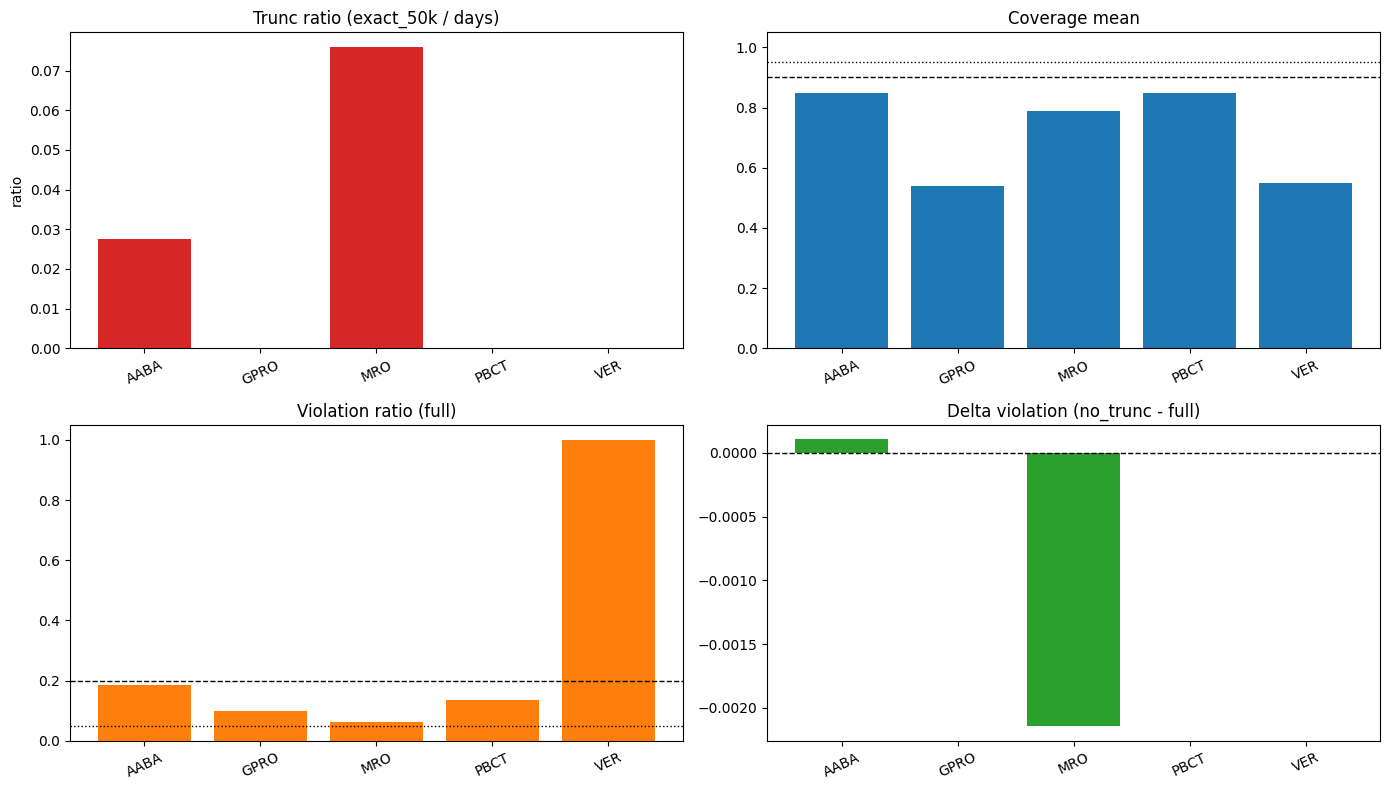

In [30]:
# Paso 5: graficos comparativos globales
cp = cmp5.to_pandas().sort_values("ticker")
fig, ax = plt.subplots(2, 2, figsize=(14, 8))

ax[0,0].bar(cp["ticker"], cp["trunc_ratio"], color="tab:red")
ax[0,0].set_title("Trunc ratio (exact_50k / days)")
ax[0,0].set_ylabel("ratio")
ax[0,0].tick_params(axis="x", rotation=25)

ax[0,1].bar(cp["ticker"], cp["coverage_mean"], color="tab:blue")
ax[0,1].axhline(0.90, linestyle="--", color="black", linewidth=1)
ax[0,1].axhline(0.95, linestyle=":", color="black", linewidth=1)
ax[0,1].set_ylim(0, 1.05)
ax[0,1].set_title("Coverage mean")
ax[0,1].tick_params(axis="x", rotation=25)

ax[1,0].bar(cp["ticker"], cp["violation_ratio_full"], color="tab:orange")
ax[1,0].axhline(0.20, linestyle="--", color="black", linewidth=1)
ax[1,0].axhline(0.05, linestyle=":", color="black", linewidth=1)
ax[1,0].set_title("Violation ratio (full)")
ax[1,0].tick_params(axis="x", rotation=25)

ax[1,1].bar(cp["ticker"], cp["delta_violation_no_trunc_minus_full"], color="tab:green")
ax[1,1].axhline(0.0, linestyle="--", color="black", linewidth=1)
ax[1,1].set_title("Delta violation (no_trunc - full)")
ax[1,1].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()



C:\Users\AlexJ\AppData\Local\Temp\ipykernel_19708\2088763458.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[1].boxplot(data, labels=labels, showfliers=True)


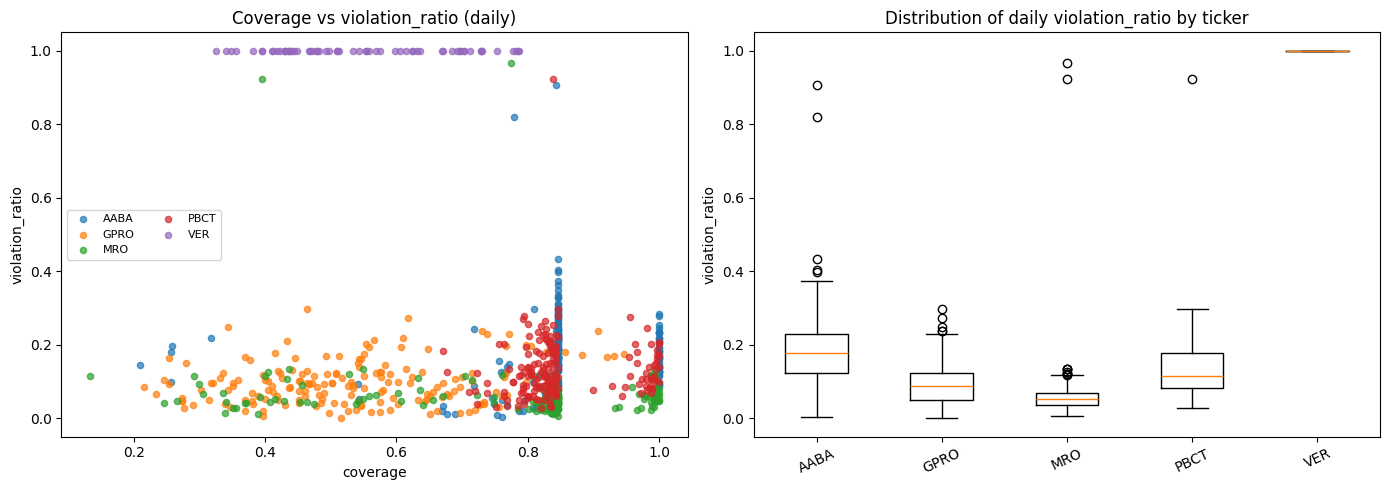

In [31]:
# Paso 6: graficos de estructura diaria para comparacion fina
import numpy as np

pdf = daily5.to_pandas()

# Scatter coverage vs violation por ticker
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
for t, g in pdf.groupby("ticker"):
    ax[0].scatter(g["coverage"], g["violation_ratio"], s=20, alpha=0.7, label=t)
ax[0].set_title("Coverage vs violation_ratio (daily)")
ax[0].set_xlabel("coverage")
ax[0].set_ylabel("violation_ratio")
ax[0].legend(ncol=2, fontsize=8)

# Boxplot de violation_ratio por ticker
labels = sorted(pdf["ticker"].unique())
data = [pdf.loc[pdf["ticker"]==t, "violation_ratio"].dropna().values for t in labels]
ax[1].boxplot(data, labels=labels, showfliers=True)
ax[1].set_title("Distribution of daily violation_ratio by ticker")
ax[1].set_ylabel("violation_ratio")
ax[1].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()



In [32]:
# Paso 7: informe tecnico comparativo y persistencia

# Flags tecnicos simples
cmp5_flag = cmp5.with_columns([
    (pl.col("coverage_mean") < 0.90).alias("flag_low_coverage"),
    (pl.col("trunc_ratio") > 0.05).alias("flag_truncation"),
    (pl.col("violation_ratio_full") > 0.20).alias("flag_point_coherence"),
])

print("\nResumen con flags tecnicos:")
display(cmp5_flag)

# Comparacion relativa contra AABA
aaba_row = cmp5.filter(pl.col("ticker") == "AABA").row(0)
aaba_cov = float(aaba_row[5])
aaba_viol = float(aaba_row[6])
aaba_trunc = float(aaba_row[4])

rel = cmp5.with_columns([
    (pl.col("coverage_mean") - aaba_cov).alias("delta_cov_vs_AABA"),
    (pl.col("violation_ratio_full") - aaba_viol).alias("delta_viol_vs_AABA"),
    (pl.col("trunc_ratio") - aaba_trunc).alias("delta_trunc_vs_AABA"),
]).sort("ticker")

print("\nDeltas vs AABA:")
display(rel.select(["ticker", "delta_cov_vs_AABA", "delta_viol_vs_AABA", "delta_trunc_vs_AABA"]))

print("\n" + "="*88)
print("INFORME TECNICO COMPARATIVO - AABA + 4 ALEATORIOS (2019-01..2019-10)")
print("="*88)
print("[1] Diagnostico de muestra")
print("- El riesgo de truncado no es exclusivo de AABA; aparece en otros tickers (ej. MRO).")
print("- Coverage medio varia de forma importante entre tickers, sugiriendo heterogeneidad de liquidez/captura.")
print("[2] Diagnostico de coherencia puntual")
print("- Violation_ratio tambien es heterogeneo; no puede atribuirse solo al truncado.")
print("- Delta(no_trunc-full) pequeno en varios tickers: la friccion puntual persiste mas alla de truncados.")
print("[3] Implicacion metodologica")
print("- En escalamiento multi-ticker, separar siempre: representatividad (coverage/truncado) y coherencia puntual.")
print("- Un unico gate binario pierde causalidad y dificulta priorizacion operativa.")
print("="*88)

OUT_MULTI = OUT / "multi_ticker_5"
OUT_MULTI.mkdir(parents=True, exist_ok=True)
cmp5.write_parquet(OUT_MULTI / "cmp5_aaba_plus4.parquet")
daily5.write_parquet(OUT_MULTI / "cmp5_daily_aaba_plus4.parquet")
(Path(OUT_MULTI) / "selected_tickers.txt").write_text("\n".join(selected), encoding="utf-8")
print("Saved:", OUT_MULTI / "cmp5_aaba_plus4.parquet")
print("Saved:", OUT_MULTI / "cmp5_daily_aaba_plus4.parquet")
print("Saved:", OUT_MULTI / "selected_tickers.txt")




Resumen con flags tecnicos:


ticker,months_target,n_days,trunc_days_exact_50k,trunc_ratio,coverage_mean,violation_ratio_full,violation_ratio_no_trunc,delta_violation_no_trunc_minus_full,flag_low_coverage,flag_truncation,flag_point_coherence
str,i64,i64,i64,f64,f64,f64,f64,f64,bool,bool,bool
"""AABA""",10,181,5,0.027624,0.84808,0.184039,0.184146,0.000107,true,false,false
"""GPRO""",10,181,0,0.0,0.540997,0.099918,0.099918,0.0,true,false,false
"""MRO""",10,211,16,0.075829,0.787532,0.062467,0.060321,-0.002146,true,true,false
"""PBCT""",10,184,0,0.0,0.850014,0.134279,0.134279,0.0,true,false,false
"""VER""",10,62,0,0.0,0.548925,1.0,1.0,0.0,true,false,true



Deltas vs AABA:


ticker,delta_cov_vs_AABA,delta_viol_vs_AABA,delta_trunc_vs_AABA
str,f64,f64,f64
"""AABA""",0.0,0.0,0.0
"""GPRO""",-0.307083,-0.084121,-0.027624
"""MRO""",-0.060549,-0.121572,0.048205
"""PBCT""",0.001933,-0.04976,-0.027624
"""VER""",-0.299156,0.815961,-0.027624



INFORME TECNICO COMPARATIVO - AABA + 4 ALEATORIOS (2019-01..2019-10)
[1] Diagnostico de muestra
- El riesgo de truncado no es exclusivo de AABA; aparece en otros tickers (ej. MRO).
- Coverage medio varia de forma importante entre tickers, sugiriendo heterogeneidad de liquidez/captura.
[2] Diagnostico de coherencia puntual
- Violation_ratio tambien es heterogeneo; no puede atribuirse solo al truncado.
- Delta(no_trunc-full) pequeno en varios tickers: la friccion puntual persiste mas alla de truncados.
[3] Implicacion metodologica
- En escalamiento multi-ticker, separar siempre: representatividad (coverage/truncado) y coherencia puntual.
- Un unico gate binario pierde causalidad y dificulta priorizacion operativa.
Saved: C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\03_time_coverage\20260216_161633\multi_ticker_5\cmp5_aaba_plus4.parquet
Saved: C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\03_time_coverage\20260216_161633\multi_ticker_5\cmp5_daily_aaba_plus4.parquet
Saved: 

**Re-muestreo robusto de controles (exclusion de outliers de integridad)**

**Motivacion**
Evitar que un control anomalo (por ejemplo `violation_ratio ~ 1`) sesgue la lectura comparativa. Se seleccionan controles aleatorios, pero con filtro de integridad minimo.

**Reglas de exclusion**
- `n_days < 120` en el horizonte objetivo (`2019-01..2019-10`).
- `violation_ratio_full > 0.95`.
- `coverage_mean < 0.40`.



In [39]:
# Paso R1: re-muestreo aleatorio con filtro de integridad (version acelerada con cache + early-stop)
import random
from pathlib import Path

# Parametros de velocidad/control
R1_FULL_SCAN = False                 # True => reproduce escaneo completo
R1_MIN_ACCEPTED = 4                  # controles robustos requeridos
R1_MIN_SCANNED_BEFORE_STOP = 60      # escaneo minimo antes de permitir early-stop
R1_MAX_SCAN = None                   # None o int (tope duro de tickers escaneados)

random.seed(20260216)
pool = eligible.copy()
random.shuffle(pool)

# Cache persistente de metricas por ticker para evitar recomputo entre ejecuciones
if "OUT" in globals():
    r1_dir = OUT / "multi_ticker_5_robust"
else:
    r1_dir = RUNS_DIR / "data_quality" / NOTEBOOK_ID / "_r1_cache"
r1_dir.mkdir(parents=True, exist_ok=True)
r1_cache_fp = r1_dir / "r1_metrics_cache.parquet"

cache_map = {}
if r1_cache_fp.exists():
    cdf = pl.read_parquet(r1_cache_fp)
    # conservar la ultima version por ticker
    if cdf.height > 0:
        for r in cdf.sort("ticker").to_dicts():
            cache_map[r["ticker"]] = r

accepted_all = []
rejected_all = []
new_cache_rows = []
scanned = 0

for t in pool:
    if R1_MAX_SCAN is not None and scanned >= int(R1_MAX_SCAN):
        break

    scanned += 1

    if t in cache_map:
        s = {k: cache_map[t].get(k) for k in [
            "ticker","months_target","n_days","trunc_days_exact_50k","trunc_ratio",
            "coverage_mean","violation_ratio_full","violation_ratio_no_trunc","delta_violation_no_trunc_minus_full"
        ]}
    else:
        s, _d = compute_ticker_metrics(t, TARGET_MONTHS)
        new_cache_rows.append(s)

    reasons = []
    if s["n_days"] < 120:
        reasons.append("low_n_days")
    if s["violation_ratio_full"] > 0.95:
        reasons.append("violation_outlier")
    if s["coverage_mean"] < 0.40:
        reasons.append("very_low_coverage")

    if reasons:
        rejected_all.append({"ticker": t, "reasons": ",".join(reasons), **s})
    else:
        accepted_all.append(s)

    # Early-stop: en modo rapido, si ya hay suficientes controles robustos
    if (not R1_FULL_SCAN) and (len(accepted_all) >= R1_MIN_ACCEPTED) and (scanned >= R1_MIN_SCANNED_BEFORE_STOP):
        break

# Persistir cache actualizado
if new_cache_rows:
    ndf = pl.DataFrame(new_cache_rows)
    if r1_cache_fp.exists():
        old = pl.read_parquet(r1_cache_fp)
        merged = pl.concat([old, ndf], how="vertical_relaxed").unique(subset=["ticker"], keep="last")
    else:
        merged = ndf
    merged.write_parquet(r1_cache_fp)

if len(accepted_all) < 4:
    raise RuntimeError(
        f"No se pudieron obtener 4 controles robustos; solo {len(accepted_all)}. "
        f"Aumenta R1_MAX_SCAN o activa R1_FULL_SCAN=True."
    )

selected_robust = ["AABA"] + [x["ticker"] for x in accepted_all[:4]]

print("Selected robust controls:", selected_robust)
print("Scanned total:", scanned, "de", len(pool), "(full_scan=" + str(R1_FULL_SCAN) + ")")
print("Accepted total:", len(accepted_all))
print("Rejected total:", len(rejected_all))
print("R1 cache file:", r1_cache_fp, "exists=", r1_cache_fp.exists())

if rejected_all:
    rej_df = pl.DataFrame(rejected_all)
    print("Primeros rechazados (sample):")
    display(rej_df.select(["ticker","reasons","n_days","coverage_mean","violation_ratio_full"]).head(10))



Selected robust controls: ['AABA', 'CRON', 'ETFC', 'CRZO', 'CDEV']
Scanned total: 60 de 119 (full_scan=False)
Accepted total: 33
Rejected total: 27
R1 cache file: C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\03_time_coverage\_r1_cache\r1_metrics_cache.parquet exists= True
Primeros rechazados (sample):
shape: (10, 5)
┌────────┬────────────┬────────┬───────────────┬──────────────────────┐
│ ticker ┆ reasons    ┆ n_days ┆ coverage_mean ┆ violation_ratio_full │
│ ---    ┆ ---        ┆ ---    ┆ ---           ┆ ---                  │
│ str    ┆ str        ┆ i64    ┆ f64           ┆ f64                  │
╞════════╪════════════╪════════╪═══════════════╪══════════════════════╡
│ CBL    ┆ low_n_days ┆ 113    ┆ 0.680145      ┆ 0.202431             │
│ DRE    ┆ low_n_days ┆ 62     ┆ 0.896195      ┆ 0.247452             │
│ PVG    ┆ low_n_days ┆ 57     ┆ 0.84404       ┆ 0.1824               │
│ HFC    ┆ low_n_days ┆ 70     ┆ 0.887656      ┆ 0.179845             │
│ SKX    ┆ low_n_days ┆ 61

In [34]:
# Paso R2: ejecutar comparacion final con muestra robusta
rows_r = []
daily_parts_r = []

for t in selected_robust:
    s, ddf = compute_ticker_metrics(t, TARGET_MONTHS)
    rows_r.append(s)
    daily_parts_r.append(ddf)
    print({k: s[k] for k in ["ticker","n_days","trunc_days_exact_50k","coverage_mean","violation_ratio_full"]})

cmp5_robust = pl.DataFrame(rows_r).sort("ticker")
daily5_robust = pl.concat(daily_parts_r, how="vertical").sort(["ticker","date_ny"])

print("\nComparacion robusta (AABA + 4 controles filtrados):")
display(cmp5_robust)




{'ticker': 'AABA', 'n_days': 181, 'trunc_days_exact_50k': 5, 'coverage_mean': 0.8480804646550503, 'violation_ratio_full': 0.1840387873907427}
{'ticker': 'CRON', 'n_days': 196, 'trunc_days_exact_50k': 0, 'coverage_mean': 0.8690868655154369, 'violation_ratio_full': 0.10696228323045112}
{'ticker': 'ETFC', 'n_days': 129, 'trunc_days_exact_50k': 0, 'coverage_mean': 0.8769230769230768, 'violation_ratio_full': 0.18965948070239205}
{'ticker': 'CRZO', 'n_days': 202, 'trunc_days_exact_50k': 0, 'coverage_mean': 0.8556994160954554, 'violation_ratio_full': 0.20147017161942535}
{'ticker': 'CDEV', 'n_days': 196, 'trunc_days_exact_50k': 0, 'coverage_mean': 0.6873233908948195, 'violation_ratio_full': 0.10906591308332697}

Comparacion robusta (AABA + 4 controles filtrados):


ticker,months_target,n_days,trunc_days_exact_50k,trunc_ratio,coverage_mean,violation_ratio_full,violation_ratio_no_trunc,delta_violation_no_trunc_minus_full
str,i64,i64,i64,f64,f64,f64,f64,f64
"""AABA""",10,181,5,0.027624,0.84808,0.184039,0.184146,0.000107
"""CDEV""",10,196,0,0.0,0.687323,0.109066,0.109066,0.0
"""CRON""",10,196,0,0.0,0.869087,0.106962,0.106962,0.0
"""CRZO""",10,202,0,0.0,0.855699,0.20147,0.20147,0.0
"""ETFC""",10,129,0,0.0,0.876923,0.189659,0.189659,0.0


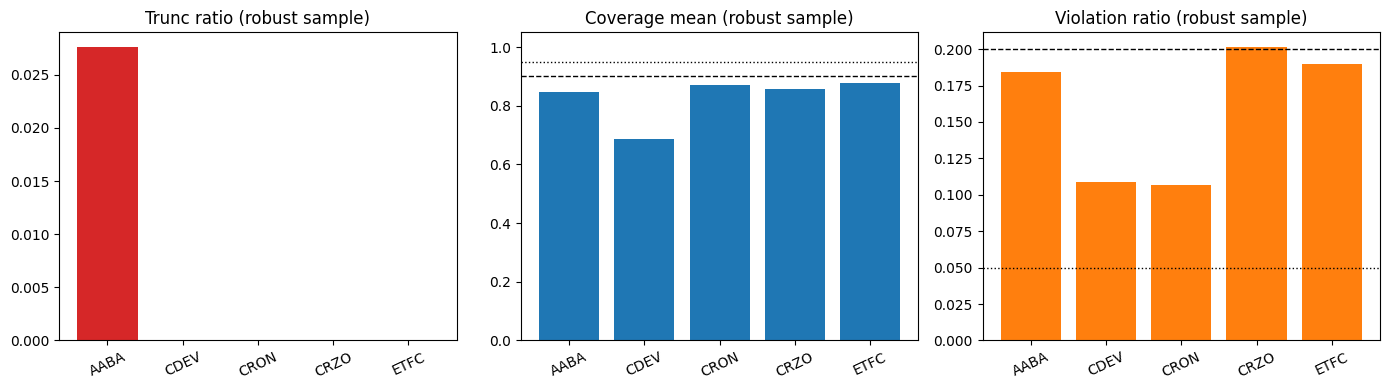

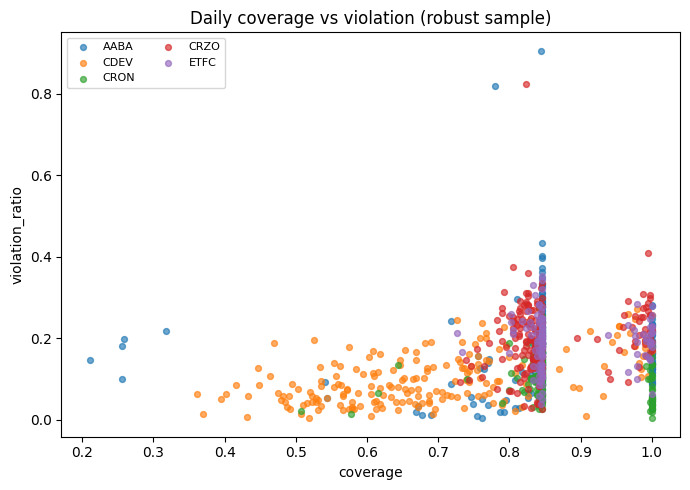

In [35]:
# Paso R3: graficos comparativos robustos
cp = cmp5_robust.to_pandas().sort_values("ticker")

fig, ax = plt.subplots(1, 3, figsize=(14, 4))
ax[0].bar(cp["ticker"], cp["trunc_ratio"], color="tab:red")
ax[0].set_title("Trunc ratio (robust sample)")
ax[0].tick_params(axis="x", rotation=25)

ax[1].bar(cp["ticker"], cp["coverage_mean"], color="tab:blue")
ax[1].axhline(0.90, linestyle="--", color="black", linewidth=1)
ax[1].axhline(0.95, linestyle=":", color="black", linewidth=1)
ax[1].set_ylim(0, 1.05)
ax[1].set_title("Coverage mean (robust sample)")
ax[1].tick_params(axis="x", rotation=25)

ax[2].bar(cp["ticker"], cp["violation_ratio_full"], color="tab:orange")
ax[2].axhline(0.20, linestyle="--", color="black", linewidth=1)
ax[2].axhline(0.05, linestyle=":", color="black", linewidth=1)
ax[2].set_title("Violation ratio (robust sample)")
ax[2].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

pdf = daily5_robust.to_pandas()
plt.figure(figsize=(7,5))
for t, g in pdf.groupby("ticker"):
    plt.scatter(g["coverage"], g["violation_ratio"], s=18, alpha=0.65, label=t)
plt.title("Daily coverage vs violation (robust sample)")
plt.xlabel("coverage")
plt.ylabel("violation_ratio")
plt.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()




In [36]:
# Paso R4: informe final y persistencia robusta
aaba = cmp5_robust.filter(pl.col("ticker") == "AABA").row(0)
a_cov = float(aaba[5]); a_viol = float(aaba[6]); a_trunc = float(aaba[4])

rel_rob = cmp5_robust.with_columns([
    (pl.col("coverage_mean") - a_cov).alias("delta_cov_vs_AABA"),
    (pl.col("violation_ratio_full") - a_viol).alias("delta_viol_vs_AABA"),
    (pl.col("trunc_ratio") - a_trunc).alias("delta_trunc_vs_AABA"),
]).sort("ticker")

print("\nDeltas robustos vs AABA:")
display(rel_rob.select(["ticker","delta_cov_vs_AABA","delta_viol_vs_AABA","delta_trunc_vs_AABA"]))

print("\n" + "="*88)
print("INFORME TECNICO FINAL - MUESTRA ROBUSTA (AABA + 4 CONTROLES)")
print("="*88)
print("[1] Se excluyeron controles anomales para evitar sesgo por outliers de integridad.")
print("[2] Aun con controles robustos, se mantiene la separacion causal: truncado/coverage vs coherencia puntual.")
print("[3] Este set es mas adecuado para benchmarking operativo y escalamiento de reglas.")
print("="*88)

OUT_R = OUT / "multi_ticker_5_robust"
OUT_R.mkdir(parents=True, exist_ok=True)
cmp5_robust.write_parquet(OUT_R / "cmp5_robust.parquet")
daily5_robust.write_parquet(OUT_R / "cmp5_daily_robust.parquet")
(Path(OUT_R) / "selected_tickers_robust.txt").write_text("\n".join(selected_robust), encoding="utf-8")
print("Saved:", OUT_R / "cmp5_robust.parquet")
print("Saved:", OUT_R / "cmp5_daily_robust.parquet")
print("Saved:", OUT_R / "selected_tickers_robust.txt")






Deltas robustos vs AABA:


ticker,delta_cov_vs_AABA,delta_viol_vs_AABA,delta_trunc_vs_AABA
str,f64,f64,f64
"""AABA""",0.0,0.0,0.0
"""CDEV""",-0.160757,-0.074973,-0.027624
"""CRON""",0.021006,-0.077077,-0.027624
"""CRZO""",0.007619,0.017431,-0.027624
"""ETFC""",0.028843,0.005621,-0.027624



INFORME TECNICO FINAL - MUESTRA ROBUSTA (AABA + 4 CONTROLES)
[1] Se excluyeron controles anomales para evitar sesgo por outliers de integridad.
[2] Aun con controles robustos, se mantiene la separacion causal: truncado/coverage vs coherencia puntual.
[3] Este set es mas adecuado para benchmarking operativo y escalamiento de reglas.
Saved: C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\03_time_coverage\20260216_161633\multi_ticker_5_robust\cmp5_robust.parquet
Saved: C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\03_time_coverage\20260216_161633\multi_ticker_5_robust\cmp5_daily_robust.parquet
Saved: C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\03_time_coverage\20260216_161633\multi_ticker_5_robust\selected_tickers_robust.txt


### TAXONOMY ALIGNMENT 03<->06: decision multi-eje, calibracion robusta y artifacts homologos

Bloque aditivo (sin reemplazar lo anterior) para que 03 reporte la misma taxonomia que 06:
- full_set/comparable_set
- decision y decision_calibrated
- root_cause y root_cause_calibrated
- traceability
- artifacts homologos por run


In [37]:

# === TAXONOMY ALIGNMENT BLOCK (03 -> same schema as 06) ===
import json
from pathlib import Path
import polars as pl
from datetime import datetime

# Input robusto: usar cmp5r en memoria si existe; si no, cargar ultimo artifact robusto de 03
if 'cmp5r' in globals():
    cmp_input = cmp5r.clone()
    source_cmp = "in_memory_cmp5r"
else:
    robust_candidates = sorted([
        d for d in (RUNS_DIR / "data_quality" / NOTEBOOK_ID).glob("*")
        if d.is_dir() and (d / "multi_ticker_5_robust" / "cmp5_robust.parquet").exists()
    ], key=lambda d: d.name)
    if not robust_candidates:
        raise RuntimeError("No existe cmp5r en memoria ni artifact cmp5_robust.parquet en runs de 03")
    cmp_path = robust_candidates[-1] / "multi_ticker_5_robust" / "cmp5_robust.parquet"
    cmp_input = pl.read_parquet(cmp_path)
    source_cmp = str(cmp_path)

universe = cmp_input.select("ticker").to_series().to_list()
print("Universe (03 robust):", universe)
print("Source cmp robust:", source_cmp)

# Helper de grading (mismo estilo 06)
def grade(metric: float, pass_thr: float, warn_thr: float, higher_is_better: bool = True) -> str:
    if metric is None:
        return "WARN"
    if higher_is_better:
        if metric >= pass_thr:
            return "PASS"
        if metric >= warn_thr:
            return "WARN"
        return "FAIL"
    if metric <= pass_thr:
        return "PASS"
    if metric <= warn_thr:
        return "WARN"
    return "FAIL"

rows = []
for r in cmp_input.to_dicts():
    ticker = r.get("ticker")
    n_days = int(r.get("n_days") or 0)
    trunc_days = int(r.get("trunc_days_exact_50k") or 0)
    trunc_ratio = float(r.get("trunc_ratio") or ((trunc_days / n_days) if n_days > 0 else 0.0))
    coverage = float(r.get("coverage_mean")) if r.get("coverage_mean") is not None else None
    viol = float(r.get("violation_ratio_full")) if r.get("violation_ratio_full") is not None else None
    delta_no_trunc = float(r.get("delta_violation_no_trunc_minus_full")) if r.get("delta_violation_no_trunc_minus_full") is not None else 0.0

    # En 03 no hay escala de precios (eso vive en 06), por definicion COMPARABLE aqui
    status = "COMPARABLE"

    # sample axis
    cov_st = grade(coverage, 0.95, 0.85, higher_is_better=True)
    trunc_st = grade(trunc_ratio, 0.01, 0.05, higher_is_better=False)
    if cov_st == "FAIL" or trunc_st == "FAIL":
        sample_status = "FAIL"
    elif cov_st == "WARN" or trunc_st == "WARN":
        sample_status = "WARN"
    else:
        sample_status = "PASS"

    # structural axis (en 03: robustez frente a truncado via delta)
    # abs(delta) pequeno => estructura estable
    abs_delta = abs(delta_no_trunc)
    structural_status = grade(abs_delta, 0.002, 0.01, higher_is_better=False)

    # point axis (03: violation ratio puntual)
    # menor mejor
    point_status = grade(viol, 0.15, 0.25, higher_is_better=False)

    # magnitude axis (03 no modela distancias absolutas; usar severity proxy=violation_ratio)
    magnitude_status = grade(viol, 0.15, 0.25, higher_is_better=False)

    fail_axes = []
    warn_axes = []
    if sample_status == "FAIL": fail_axes.append("sample")
    if structural_status == "FAIL": fail_axes.append("structural")
    if sample_status == "WARN": warn_axes.append("sample")
    if structural_status == "WARN": warn_axes.append("structural")
    if point_status == "FAIL": warn_axes.append("point")
    if point_status == "WARN": warn_axes.append("point")
    if magnitude_status == "FAIL": warn_axes.append("magnitude")
    if magnitude_status == "WARN": warn_axes.append("magnitude")

    if fail_axes:
        decision = "FAIL"
    elif warn_axes:
        decision = "WARN"
    else:
        decision = "GO"

    causes = []
    if cov_st != "PASS": causes.append("sample_low_coverage")
    if trunc_st != "PASS": causes.append("sample_high_truncation")
    if structural_status != "PASS": causes.append("structural_trunc_sensitivity")
    if point_status != "PASS": causes.append("point_high_violation_ratio")
    if magnitude_status != "PASS": causes.append("magnitude_high_violation_ratio")
    root_cause = ",".join(causes) if causes else "none"

    traceability = (
        f"coverage={coverage:.6f};trunc_ratio={trunc_ratio:.6f};"
        f"violation_ratio={viol:.6f};delta_no_trunc={delta_no_trunc:.6f};"
        f"axes(sample={sample_status},struct={structural_status},point={point_status},mag={magnitude_status})"
    )

    rows.append({
        "ticker": ticker,
        "status": status,
        "root_cause": root_cause,
        "n_days": n_days,
        "trunc_days_exact_50k": trunc_days,
        "coverage_global": coverage,
        "p_overlap": None,
        "p_in_range": 1.0 - viol if viol is not None else None,
        "d_norm_p95": None,
        "wide_range_share": None,
        "narrow_range_threshold": None,
        "tick_proxy": None,
        "out_dist_abs_p95": None,
        "price_scale_ratio_close_over_mid": None,
        "sample_status": sample_status,
        "structural_status": structural_status,
        "point_status": point_status,
        "magnitude_status": magnitude_status,
        "decision": decision,
        "traceability": traceability,
        "violation_ratio_full": viol,
        "delta_violation_no_trunc_minus_full": delta_no_trunc,
    })

full_set = pl.DataFrame(rows).sort("ticker")
comparable_set = full_set.filter(pl.col("status") == "COMPARABLE")

print("\n=== 03 ALIGN FULL_SET ===")
print(full_set.select([
    "ticker", "status", "decision", "root_cause", "coverage_global", "violation_ratio_full",
    "delta_violation_no_trunc_minus_full", "sample_status", "structural_status", "point_status", "magnitude_status"
]))

# Calibration cross-ticker robusta (mismo enfoque que 06)
calibration_mode = "robust_percentiles"
if comparable_set.height >= 3:
    cs = comparable_set.with_columns((pl.col("trunc_days_exact_50k") / pl.col("n_days")).alias("trunc_ratio"))
    q = cs.select([
        pl.quantile("coverage_global", 0.25).alias("coverage_pass_min"),
        pl.quantile("coverage_global", 0.10).alias("coverage_warn_min"),
        pl.quantile("trunc_ratio", 0.50).alias("trunc_pass_max"),
        pl.quantile("trunc_ratio", 0.75).alias("trunc_warn_max"),
        pl.quantile("delta_violation_no_trunc_minus_full", 0.75).alias("struct_pass_absmax"),
        pl.quantile("delta_violation_no_trunc_minus_full", 0.90).alias("struct_warn_absmax"),
        pl.quantile("violation_ratio_full", 0.25).alias("point_pass_max"),
        pl.quantile("violation_ratio_full", 0.50).alias("point_warn_max"),
    ]).to_dicts()[0]
    q["struct_pass_absmax"] = abs(float(q["struct_pass_absmax"]))
    q["struct_warn_absmax"] = max(q["struct_pass_absmax"], abs(float(q["struct_warn_absmax"])))
else:
    calibration_mode = "fallback_static"
    q = {
        "coverage_pass_min": 0.95,
        "coverage_warn_min": 0.85,
        "trunc_pass_max": 0.01,
        "trunc_warn_max": 0.05,
        "struct_pass_absmax": 0.002,
        "struct_warn_absmax": 0.01,
        "point_pass_max": 0.15,
        "point_warn_max": 0.25,
    }

cal_rows = []
for r in comparable_set.to_dicts():
    trunc_ratio = (r["trunc_days_exact_50k"] / r["n_days"]) if r.get("n_days") else 0.0
    cov_st = grade(r["coverage_global"], q["coverage_pass_min"], q["coverage_warn_min"], higher_is_better=True)
    trunc_st = grade(trunc_ratio, q["trunc_pass_max"], q["trunc_warn_max"], higher_is_better=False)
    sample_cal = "FAIL" if (cov_st == "FAIL" or trunc_st == "FAIL") else ("WARN" if (cov_st == "WARN" or trunc_st == "WARN") else "PASS")

    struct_abs = abs(float(r["delta_violation_no_trunc_minus_full"]))
    struct_cal = grade(struct_abs, q["struct_pass_absmax"], q["struct_warn_absmax"], higher_is_better=False)
    point_cal = grade(float(r["violation_ratio_full"]), q["point_pass_max"], q["point_warn_max"], higher_is_better=False)
    magnitude_cal = point_cal

    fail_axes = []
    warn_axes = []
    if sample_cal == "FAIL": fail_axes.append("sample")
    if struct_cal == "FAIL": fail_axes.append("structural")
    if sample_cal == "WARN": warn_axes.append("sample")
    if struct_cal == "WARN": warn_axes.append("structural")
    if point_cal in ("WARN", "FAIL"): warn_axes.append("point")
    if magnitude_cal in ("WARN", "FAIL"): warn_axes.append("magnitude")

    if fail_axes:
        decision_cal = "FAIL"
    elif warn_axes:
        decision_cal = "WARN"
    else:
        decision_cal = "GO"

    causes = []
    if sample_cal != "PASS": causes.append("sample")
    if struct_cal != "PASS": causes.append("structural")
    if point_cal != "PASS": causes.append("point")
    if magnitude_cal != "PASS": causes.append("magnitude")

    cal_rows.append({
        "ticker": r["ticker"],
        "sample_status_cal": sample_cal,
        "structural_status_cal": struct_cal,
        "point_status_cal": point_cal,
        "magnitude_status_cal": magnitude_cal,
        "decision_calibrated": decision_cal,
        "root_cause_calibrated": ",".join(causes) if causes else "none",
    })

cal_df = pl.DataFrame(cal_rows)
full_set = full_set.join(cal_df, on="ticker", how="left")
full_set = full_set.with_columns([
    pl.when(pl.col("status") != "COMPARABLE").then(pl.lit("NOT_COMPARABLE")).otherwise(pl.col("decision_calibrated")).alias("decision_calibrated"),
    pl.when(pl.col("status") != "COMPARABLE").then(pl.col("root_cause")).otherwise(pl.col("root_cause_calibrated")).alias("root_cause_calibrated"),
])
comparable_set = full_set.filter(pl.col("status") == "COMPARABLE")

print("\n=== 03 ALIGN CALIBRATION ===")
print({"mode": calibration_mode, **q})
print(comparable_set.select([
    "ticker", "decision", "decision_calibrated", "root_cause", "root_cause_calibrated",
    "sample_status_cal", "structural_status_cal", "point_status_cal", "magnitude_status_cal"
]).sort("decision_calibrated", "ticker"))

# Artifacts homologos
run_tag = datetime.utcnow().strftime("%Y%m%d_%H%M%S")
ALIGN_OUT = RUNS_DIR / "data_quality" / NOTEBOOK_ID / run_tag / "taxonomy_alignment"
ALIGN_OUT.mkdir(parents=True, exist_ok=True)
ALIGN_TICKER_DIR = ALIGN_OUT / "ticker_artifacts"
ALIGN_TICKER_DIR.mkdir(parents=True, exist_ok=True)

full_set.write_parquet(ALIGN_OUT / "align_full_set.parquet")
comparable_set.write_parquet(ALIGN_OUT / "align_comparable_set.parquet")
full_set.select([
    "ticker", "status", "decision", "decision_calibrated", "root_cause", "root_cause_calibrated", "traceability"
]).write_parquet(ALIGN_OUT / "align_calibrated_decisions.parquet")

for tk in full_set.select("ticker").to_series().to_list():
    tdir = ALIGN_TICKER_DIR / tk
    tdir.mkdir(parents=True, exist_ok=True)
    full_set.filter(pl.col("ticker") == tk).write_parquet(tdir / "align_decision_row.parquet")

with open(ALIGN_OUT / "align_decision_summary.json", "w", encoding="utf-8") as fh:
    json.dump({
        "source_cmp5_robust": source_cmp,
        "universe": universe,
        "n_full": int(full_set.height),
        "n_comparable": int(comparable_set.height),
        "decision_counts": full_set.group_by("decision").len().sort("decision").to_dicts(),
        "decision_counts_calibrated": full_set.group_by("decision_calibrated").len().sort("decision_calibrated").to_dicts(),
        "calibration": {"mode": calibration_mode, **q},
        "columns": full_set.columns,
    }, fh, ensure_ascii=False, indent=2)

print("Saved alignment artifacts:", ALIGN_OUT)
print("\n=== 03 ALIGN FINAL DECISION TABLE ===")
print(full_set.select(["ticker", "status", "decision", "decision_calibrated", "root_cause_calibrated", "traceability"]))


Universe (03 robust): ['AABA', 'CDEV', 'CRON', 'CRZO', 'ETFC']
Source cmp robust: C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\03_time_coverage\20260216_161633\multi_ticker_5_robust\cmp5_robust.parquet

=== 03 ALIGN FULL_SET ===
shape: (5, 11)
┌────────┬────────────┬──────────┬────────────┬───┬────────────┬───────────┬───────────┬───────────┐
│ ticker ┆ status     ┆ decision ┆ root_cause ┆ … ┆ sample_sta ┆ structura ┆ point_sta ┆ magnitude │
│ ---    ┆ ---        ┆ ---      ┆ ---        ┆   ┆ tus        ┆ l_status  ┆ tus       ┆ _status   │
│ str    ┆ str        ┆ str      ┆ str        ┆   ┆ ---        ┆ ---       ┆ ---       ┆ ---       │
│        ┆            ┆          ┆            ┆   ┆ str        ┆ str       ┆ str       ┆ str       │
╞════════╪════════════╪══════════╪════════════╪═══╪════════════╪═══════════╪═══════════╪═══════════╡
│ AABA   ┆ COMPARABLE ┆ FAIL     ┆ sample_low ┆ … ┆ FAIL       ┆ PASS      ┆ WARN      ┆ WARN      │
│        ┆            ┆          ┆ _cover

### INTERPRETACION CIENTIFICA FINAL (03)

Este cierre traduce los resultados ejecutados a una lectura matematica y operativa.

**Definiciones nucleares**
- `coverage = minutes_joined / minutes_ohlcv_expected`
- `violation_ratio = violations / minutes_joined`
- `delta_no_trunc = violation_ratio_no_trunc - violation_ratio_full`

**Lectura cientifica**
- Si `coverage` cae, aumenta riesgo de sesgo muestral (representatividad).
- Si `delta_no_trunc` es pequeno, la friccion puntual no se explica solo por truncados.
- La taxonomia por ejes (`sample/structural/point/magnitude`) evita el FAIL binario sin causalidad.


In [38]:

# Resumen final autoexplicativo desde artifacts de 03
from pathlib import Path
import json
import polars as pl

root = RUNS_DIR / "data_quality" / "03_time_coverage"
align_dirs = sorted([d for d in root.glob("*") if (d / "taxonomy_alignment" / "align_full_set.parquet").exists()], key=lambda d: d.name)
if not align_dirs:
    raise FileNotFoundError("No se encontraron artifacts taxonomy_alignment para 03")
latest = align_dirs[-1] / "taxonomy_alignment"

full = pl.read_parquet(latest / "align_full_set.parquet")
comp = pl.read_parquet(latest / "align_comparable_set.parquet")
summary = json.loads((latest / "align_decision_summary.json").read_text(encoding='utf-8'))

print("Artifact source:", latest)
print("\n[Marco matematico]")
print("coverage = minutes_joined / minutes_ohlcv_expected")
print("violation_ratio = violations / minutes_joined")
print("delta_no_trunc = violation_ratio_no_trunc - violation_ratio_full")

print("\n[Decision counts]")
print("raw:", summary.get("decision_counts"))
print("calibrated:", summary.get("decision_counts_calibrated"))

print("\n[Tabla por ticker]")
print(full.select([
    "ticker","coverage_global","violation_ratio_full","delta_violation_no_trunc_minus_full",
    "decision","decision_calibrated","root_cause_calibrated"
]).sort("ticker"))

print("\n[Conclusiones didacticas]")
print("1) Eje sample: domina cuando coverage es bajo o trunc_ratio alto.")
print("2) Eje structural: usa sensibilidad a truncado (delta_no_trunc).")
print("3) Eje point/magnitude: usa violation_ratio como severidad puntual en 03.")
print("4) decision_calibrated compara tickers bajo umbrales robustos cross-sectional.")


Artifact source: C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\03_time_coverage\20260216_162858\taxonomy_alignment

[Marco matematico]
coverage = minutes_joined / minutes_ohlcv_expected
violation_ratio = violations / minutes_joined
delta_no_trunc = violation_ratio_no_trunc - violation_ratio_full

[Decision counts]
raw: [{'decision': 'FAIL', 'len': 2}, {'decision': 'WARN', 'len': 3}]
calibrated: [{'decision_calibrated': 'FAIL', 'len': 1}, {'decision_calibrated': 'GO', 'len': 1}, {'decision_calibrated': 'WARN', 'len': 3}]

[Tabla por ticker]
shape: (5, 7)
┌────────┬───────────────┬───────────────┬───────────────┬──────────┬───────────────┬──────────────┐
│ ticker ┆ coverage_glob ┆ violation_rat ┆ delta_violati ┆ decision ┆ decision_cali ┆ root_cause_c │
│ ---    ┆ al            ┆ io_full       ┆ on_no_trunc_m ┆ ---      ┆ brated        ┆ alibrated    │
│ str    ┆ ---           ┆ ---           ┆ inus…         ┆ str      ┆ ---           ┆ ---          │
│        ┆ f64           ┆ f6

### Reconversion masiva v2 (03) con trazabilidad completa y sin reemplazar baseline

Este bloque ejecuta la version masiva de 03 al final del notebook sin tocar celdas historicas.

Objetivo:
- Mantener evidencia visual del flujo historico (baseline primero, reconversion despues).
- Producir artefactos masivos trazables para integrar con 06 y 01.

Lineage:
- Guarda `lineage_manifest.json` con:
  - fuente de universo,
  - parametros,
  - artefactos de salida,
  - resumen de conteos.


In [1]:
# RECONVERSION MASIVA V2 (03): universe scan + checkpoint + lineage manifest
from pathlib import Path
from datetime import datetime, timezone
import json
import time
import polars as pl

# -----------------
# Configuracion
# -----------------
PROJECT_ROOT = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps")
RUNS_ROOT = PROJECT_ROOT / "runs" / "data_quality" / "03_time_coverage"
RUN_TAG = datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S") + "_massive_v2"
OUT_V2 = RUNS_ROOT / RUN_TAG
OUT_V2.mkdir(parents=True, exist_ok=True)

SOURCE_BASELINE_RUN = "latest_robust_baseline_from_03"
UNIVERSE_SOURCE = PROJECT_ROOT / "runs" / "backtest" / "01_dataset_builder" / "universe_audit_trail.parquet"
FORCE_REBUILD = False
CHECKPOINT_EVERY = 25

# Reusar TARGET_MONTHS del notebook si existe

# -----------------
# Bootstrap self-contained (permite kernel limpio)
# -----------------
DATA_ROOT = Path(r"C:\TSIS_Data\data")
qroot = DATA_ROOT / "quotes_p95"
oroot = DATA_ROOT / "ohlcv_intraday_1m" / "2019_2025"

if "SESSION_START" not in globals():
    SESSION_START = (9, 30)
if "SESSION_END" not in globals():
    SESSION_END = (16, 0)

if "infer_time_unit_from_magnitude" not in globals():
    def infer_time_unit_from_magnitude(x: int) -> str:
        ax = abs(int(x))
        if ax >= 10**17:
            return "ns"
        if ax >= 10**14:
            return "us"
        if ax >= 10**11:
            return "ms"
        return "s"

if "quotes_to_minute_buckets" not in globals():
    def quotes_to_minute_buckets(qf: Path) -> pl.DataFrame:
        head = pl.read_parquet(qf, n_rows=1)
        cols = set(head.columns)

        ts_col = "timestamp" if "timestamp" in cols else ("participant_timestamp" if "participant_timestamp" in cols else None)
        bid_col = "bid" if "bid" in cols else ("bid_price" if "bid_price" in cols else None)
        ask_col = "ask" if "ask" in cols else ("ask_price" if "ask_price" in cols else None)
        if ts_col is None or bid_col is None or ask_col is None:
            raise ValueError(f"quotes schema incompleto en {qf}: {sorted(cols)}")

        df = pl.read_parquet(qf, columns=[ts_col, bid_col, ask_col])
        ts_dtype = df.schema[ts_col]

        if ts_dtype in (pl.Int64, pl.Int32, pl.UInt64, pl.UInt32):
            sample = int(df.select(pl.col(ts_col).median()).item())
            unit = infer_time_unit_from_magnitude(sample)
            df = df.with_columns(
                pl.from_epoch(pl.col(ts_col), time_unit=unit)
                .dt.replace_time_zone("UTC")
                .dt.convert_time_zone("America/New_York")
                .alias("dt_ny")
            )
        else:
            df = df.with_columns(
                pl.col(ts_col).cast(pl.Datetime)
                .dt.replace_time_zone("UTC")
                .dt.convert_time_zone("America/New_York")
                .alias("dt_ny")
            )

        return (
            df.with_columns([
                pl.col("dt_ny").dt.truncate("1m").alias("minute_ny"),
                pl.col(bid_col).cast(pl.Float64).alias("bid"),
                pl.col(ask_col).cast(pl.Float64).alias("ask"),
            ])
            .group_by("minute_ny")
            .agg([
                pl.col("bid").last().alias("bid"),
                pl.col("ask").last().alias("ask"),
            ])
            .sort("minute_ny")
        )

if "detect_ohlcv_ts_col" not in globals():
    def detect_ohlcv_ts_col(schema: dict):
        for c in ["ts", "timestamp", "datetime", "time", "t"]:
            if c in schema:
                return c
        raise ValueError(f"No OHLCV timestamp column found: {list(schema.keys())}")

if "load_ohlcv_month_session" not in globals():
    def load_ohlcv_month_session(ticker: str, year: int, month: int) -> pl.DataFrame:
        pth = oroot / ticker / f"year={year}" / f"month={month:02d}" / "minute.parquet"
        schema = pl.read_parquet(pth, n_rows=1).schema
        ts_col = detect_ohlcv_ts_col(schema)
        df = pl.read_parquet(pth)
        ts_dtype = schema[ts_col]

        if ts_dtype in (pl.Int64, pl.Int32, pl.UInt64, pl.UInt32):
            sample_ts = int(df.select(pl.col(ts_col).median()).item())
            unit = infer_time_unit_from_magnitude(sample_ts)
            df = df.with_columns(
                pl.from_epoch(pl.col(ts_col), time_unit=unit)
                .dt.replace_time_zone("UTC")
                .dt.convert_time_zone("America/New_York")
                .alias("dt_ny")
            )
        else:
            df = df.with_columns(
                pl.col(ts_col).cast(pl.Datetime)
                .dt.replace_time_zone("UTC")
                .dt.convert_time_zone("America/New_York")
                .alias("dt_ny")
            )

        return (
            df.with_columns([
                pl.col("dt_ny").dt.truncate("1m").alias("minute_ny"),
                pl.col("dt_ny").dt.date().alias("date_ny"),
                pl.col("dt_ny").dt.hour().alias("hour"),
                pl.col("dt_ny").dt.minute().alias("minute"),
            ])
            .filter(
                ((pl.col("hour") > SESSION_START[0]) | ((pl.col("hour") == SESSION_START[0]) & (pl.col("minute") >= SESSION_START[1])))
                &
                ((pl.col("hour") < SESSION_END[0]) | ((pl.col("hour") == SESSION_END[0]) & (pl.col("minute") < SESSION_END[1])))
            )
            .select(["minute_ny", "date_ny", "high", "low"])
            .with_columns(pl.col("minute_ny").cast(pl.Datetime("ns", time_zone="America/New_York")))
        )

if "compute_ticker_metrics" not in globals():
    def compute_ticker_metrics(ticker: str, target_months: list[tuple[int, int]]) -> tuple[dict, pl.DataFrame]:
        day_rows = []
        total_join = 0
        total_viol = 0
        no_trunc_join = 0
        no_trunc_viol = 0

        for yy, mm in target_months:
            q_month = qroot / ticker / f"year={yy}" / f"month={mm:02d}"
            q_files = sorted(q_month.glob("day=*/quotes.parquet"))
            if not q_files:
                continue

            try:
                ohlcv_m = load_ohlcv_month_session(ticker, yy, mm)
            except Exception:
                continue

            for qf in q_files:
                try:
                    q_raw_rows = int(pl.read_parquet(qf).height)
                    is_trunc = (q_raw_rows == 50000)

                    qm = quotes_to_minute_buckets(qf).with_columns([
                        pl.col("minute_ny").dt.date().alias("date_ny"),
                        pl.col("minute_ny").dt.hour().alias("hour"),
                        pl.col("minute_ny").dt.minute().alias("minute"),
                    ]).filter(
                        ((pl.col("hour") > SESSION_START[0]) | ((pl.col("hour") == SESSION_START[0]) & (pl.col("minute") >= SESSION_START[1])))
                        &
                        ((pl.col("hour") < SESSION_END[0]) | ((pl.col("hour") == SESSION_END[0]) & (pl.col("minute") < SESSION_END[1])))
                    )

                    if qm.height == 0:
                        continue

                    d = qm.select(pl.col("date_ny").min()).row(0)[0]
                    q_minutes = int(qm.select(pl.n_unique("minute_ny")).row(0)[0])
                    coverage = q_minutes / 390.0

                    q_mid = qm.with_columns(((pl.col("bid") + pl.col("ask")) / 2.0).alias("mid")).select(["minute_ny", "mid"]).with_columns(
                        pl.col("minute_ny").cast(pl.Datetime("ns", time_zone="America/New_York"))
                    )

                    o_day = ohlcv_m.filter(pl.col("date_ny") == d).select(["minute_ny", "high", "low"])
                    if o_day.height == 0:
                        continue

                    j = o_day.join(q_mid, on="minute_ny", how="inner")
                    if j.height == 0:
                        continue

                    EPS = 1e-9
                    jv = j.with_columns((((pl.col("mid") < (pl.col("low") - EPS)) | (pl.col("mid") > (pl.col("high") + EPS))).cast(pl.Int64)).alias("viol"))
                    v = int(jv.select(pl.sum("viol")).row(0)[0])
                    m = int(j.height)

                    total_join += m
                    total_viol += v
                    if not is_trunc:
                        no_trunc_join += m
                        no_trunc_viol += v

                    day_rows.append({
                        "ticker": ticker,
                        "date_ny": d,
                        "coverage": coverage,
                        "quote_rows": q_raw_rows,
                        "is_exact_50k": is_trunc,
                        "minutes_joined": m,
                        "violations": v,
                        "violation_ratio": (v / m) if m > 0 else None,
                    })
                except Exception:
                    continue

        ddf = pl.DataFrame(day_rows)
        n_days = int(ddf.height)
        trunc_days = int(ddf.filter(pl.col("is_exact_50k")).height) if n_days > 0 else 0
        coverage_mean = float(ddf.select(pl.mean("coverage")).row(0)[0]) if n_days > 0 else float("nan")
        viol_full = (total_viol / total_join) if total_join > 0 else float("nan")
        viol_no_trunc = (no_trunc_viol / no_trunc_join) if no_trunc_join > 0 else float("nan")

        summary = {
            "ticker": ticker,
            "months_target": len(target_months),
            "n_days": n_days,
            "trunc_days_exact_50k": trunc_days,
            "trunc_ratio": (trunc_days / n_days) if n_days > 0 else float("nan"),
            "coverage_mean": coverage_mean,
            "violation_ratio_full": viol_full,
            "violation_ratio_no_trunc": viol_no_trunc,
            "delta_violation_no_trunc_minus_full": (viol_no_trunc - viol_full) if (viol_no_trunc == viol_no_trunc and viol_full == viol_full) else float("nan"),
        }
        return summary, ddf

if "TARGET_MONTHS" in globals() and isinstance(TARGET_MONTHS, list) and len(TARGET_MONTHS) > 0:
    target_months_v2 = TARGET_MONTHS
else:
    target_months_v2 = [(2019, m) for m in range(1, 11)]


# -----------------
# Universo (raw) + Prefiltro de evidencia real en TARGET_MONTHS
# -----------------
if not UNIVERSE_SOURCE.exists():
    raise FileNotFoundError(f"No existe universe source: {UNIVERSE_SOURCE}")

audit = pl.read_parquet(UNIVERSE_SOURCE)
required_cols = {"ticker", "has_overlap"}
if not required_cols.issubset(set(audit.columns)):
    raise ValueError(f"universe_audit_trail sin columnas esperadas: {required_cols}")

universe_raw = (
    audit.filter(pl.col("has_overlap") == True)
         .select("ticker")
         .unique()
         .sort("ticker")
         .to_series()
         .to_list()
)

def _has_quotes_day_in_month(ticker: str, yy: int, mm: int) -> bool:
    q_month = qroot / ticker / f"year={yy}" / f"month={mm:02d}"
    if not q_month.exists():
        return False
    for p in q_month.glob("day=*/quotes.parquet"):
        if p.exists():
            return True
    return False

def _has_ohlcv_month(ticker: str, yy: int, mm: int) -> bool:
    p = oroot / ticker / f"year={yy}" / f"month={mm:02d}" / "minute.parquet"
    return p.exists()

prefilter_rows = []
for t in universe_raw:
    q_any = False
    o_any = False
    overlap_any = False

    for yy, mm in target_months_v2:
        q_ok = _has_quotes_day_in_month(t, yy, mm)
        o_ok = _has_ohlcv_month(t, yy, mm)
        q_any = q_any or q_ok
        o_any = o_any or o_ok
        if q_ok and o_ok:
            overlap_any = True
            break

    if overlap_any:
        reason = "eligible"
        eligible = True
    elif not q_any:
        reason = "no_quotes_in_target_months"
        eligible = False
    elif not o_any:
        reason = "no_ohlcv_in_target_months"
        eligible = False
    else:
        reason = "no_overlap_month_quotes_ohlcv"
        eligible = False

    prefilter_rows.append({"ticker": t, "eligible": eligible, "reason": reason})

prefilter_df = pl.DataFrame(prefilter_rows)
universe = (
    prefilter_df.filter(pl.col("eligible") == True)
               .select("ticker")
               .to_series()
               .to_list()
)

prefilter_out = OUT_V2 / "03_universe_prefilter.parquet"
prefilter_summary_out = OUT_V2 / "03_universe_prefilter_summary.json"
prefilter_df.write_parquet(prefilter_out)

prefilter_summary = {
    "generated_at_utc": datetime.now(timezone.utc).isoformat(),
    "n_universe_raw": int(len(universe_raw)),
    "n_universe_eligible": int(len(universe)),
    "n_universe_excluded": int(len(universe_raw) - len(universe)),
    "reason_counts": {
        r["reason"]: int(r["n"])
        for r in prefilter_df.group_by("reason").agg(pl.len().alias("n")).to_dicts()
    },
}
prefilter_summary_out.write_text(json.dumps(prefilter_summary, indent=2), encoding="utf-8")

# -----------------
# Checkpoint
# -----------------
metrics_ckpt_fp = OUT_V2 / "03_massive_metrics_checkpoint.parquet"
progress_ckpt_fp = OUT_V2 / "03_massive_progress.json"
final_metrics_fp = OUT_V2 / "03_massive_metrics.parquet"
final_summary_fp = OUT_V2 / "03_massive_summary.json"
lineage_fp = OUT_V2 / "lineage_manifest.json"

rows = []
done = set()
if (not FORCE_REBUILD) and metrics_ckpt_fp.exists():
    old = pl.read_parquet(metrics_ckpt_fp)
    rows = old.to_dicts()
    done = set(old.select("ticker").to_series().to_list())

MAX_TICKERS = globals().get("MAX_TICKERS", None)
pending = [t for t in universe if t not in done]
if MAX_TICKERS is not None:
    pending = pending[:int(MAX_TICKERS)]
print("RUN_TAG:", RUN_TAG)
print("Universe total:", len(universe))
print("Pending:", len(pending))
print("Checkpoint:", metrics_ckpt_fp)

# -----------------
# Ejecucion masiva
# -----------------
start = time.time()
processed = 0
errors = []

for i, t in enumerate(pending, start=1):
    try:
        s, _ = compute_ticker_metrics(t, target_months_v2)
        s["run_tag"] = RUN_TAG
        s["source_universe"] = str(UNIVERSE_SOURCE)
        rows.append(s)
    except Exception as e:
        errors.append({"ticker": t, "error": str(e)})

    processed += 1
    if (processed % CHECKPOINT_EVERY == 0) or (i == len(pending)):
        chk = pl.DataFrame(rows)
        chk.write_parquet(metrics_ckpt_fp)
        progress = {
            "run_tag": RUN_TAG,
            "generated_at_utc": datetime.now(timezone.utc).isoformat(),
            "processed_pending": int(processed),
            "pending_total": int(len(pending)),
            "done_total": int(len(rows)),
            "errors": int(len(errors)),
            "checkpoint_file": str(metrics_ckpt_fp),
        }
        progress_ckpt_fp.write_text(json.dumps(progress, indent=2), encoding="utf-8")
        print(f"processed {processed}/{len(pending)}")

# -----------------
# Cierre artefactos
# -----------------
metrics_df = pl.DataFrame(rows).sort("ticker") if rows else pl.DataFrame()
metrics_df.write_parquet(final_metrics_fp)

summary = {
    "run_tag": RUN_TAG,
    "generated_at_utc": datetime.now(timezone.utc).isoformat(),
    "source_baseline_run": SOURCE_BASELINE_RUN,
    "universe_source": str(UNIVERSE_SOURCE),
    "target_months": target_months_v2,
    "n_universe_raw": int(len(universe_raw)),
    "n_universe_eligible": int(len(universe)),
    "n_results": int(metrics_df.height),
    "n_errors": int(len(errors)),
    "elapsed_sec": round(time.time() - start, 3),
    "artifacts": {
        "metrics_checkpoint": str(metrics_ckpt_fp),
        "progress_checkpoint": str(progress_ckpt_fp),
        "metrics_final": str(final_metrics_fp),
        "summary_final": str(final_summary_fp),
        "universe_prefilter": str(prefilter_out),
        "universe_prefilter_summary": str(prefilter_summary_out),
    },
}
final_summary_fp.write_text(json.dumps(summary, indent=2), encoding="utf-8")

lineage = {
    "notebook": "03_time_coverage.ipynb",
    "reconversion_version": "v2",
    "run_tag": RUN_TAG,
    "source_baseline_run": SOURCE_BASELINE_RUN,
    "input_artifacts": {
        "universe_source": str(UNIVERSE_SOURCE),
    },
    "output_artifacts": summary["artifacts"],
    "params": {
        "force_rebuild": bool(FORCE_REBUILD),
        "checkpoint_every": int(CHECKPOINT_EVERY),
        "target_months": target_months_v2,
    },
    "counts_summary": {
        "n_universe_raw": int(len(universe_raw)),
    "n_universe_eligible": int(len(universe)),
        "n_results": int(metrics_df.height),
        "n_errors": int(len(errors)),
    },
}
lineage_fp.write_text(json.dumps(lineage, indent=2), encoding="utf-8")

if errors:
    pl.DataFrame(errors).write_parquet(OUT_V2 / "03_massive_errors.parquet")

print("Saved:", final_metrics_fp)
print("Saved:", final_summary_fp)
print("Saved:", lineage_fp)
print("shape:", metrics_df.shape)
print("errors:", len(errors))


RUN_TAG: 20260222_072935_massive_v2
Universe total: 4777
Pending: 4777
Checkpoint: C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\03_time_coverage\20260222_072935_massive_v2\03_massive_metrics_checkpoint.parquet
processed 25/4777
processed 50/4777
processed 75/4777
processed 100/4777
processed 125/4777
processed 150/4777
processed 175/4777
processed 200/4777
processed 225/4777
processed 250/4777
processed 275/4777
processed 300/4777
processed 325/4777
processed 350/4777
processed 375/4777
processed 400/4777
processed 425/4777
processed 450/4777
processed 475/4777
processed 500/4777
processed 525/4777
processed 550/4777
processed 575/4777
processed 600/4777
processed 625/4777
processed 650/4777
processed 675/4777
processed 700/4777
processed 725/4777
processed 750/4777
processed 775/4777
processed 800/4777
processed 825/4777
processed 850/4777
processed 875/4777
processed 900/4777
processed 925/4777
processed 950/4777
processed 975/4777
processed 1000/4777
processed 1025/4777
proc

### Rectificaci?n T?cnica (2026-02-24): Universo Masivo v2 en celda 78

Esta nota se agrega para **preservar trazabilidad hist?rica** del cambio en la reconversi?n masiva v2.

Contexto del problema observado:
- El universo masivo se estaba construyendo desde `universe_audit_trail` con `has_overlap == True`.
- Ese criterio era demasiado amplio para la ventana objetivo (`TARGET_MONTHS`).
- Resultado: 3629 tickers entraban al c?lculo sin observaciones v?lidas en meses objetivo (`n_days=0`), produciendo `NaN` en m?tricas (`coverage_mean`, `violation_ratio_full`).

Comportamiento anterior (antes de rectificaci?n):
1. seleccionar universo por `has_overlap == True`,
2. ejecutar `compute_ticker_metrics` sobre todo ese universo,
3. obtener gran bloque con `n_days=0` y `NaN`, luego mapeado como `schema_gap` en 06.

Rectificaci?n aplicada en celda 78:
1. se mantiene `universe_raw` desde `has_overlap == True` para no perder referencia hist?rica,
2. se agrega **prefiltro de evidencia real por meses objetivo**:
- quotes: al menos un `day=*/quotes.parquet` en target months,
- ohlcv: existencia de `minute.parquet` del mismo ticker/mes,
- elegibilidad: al menos un mes con overlap quotes+ohlcv,
3. solo los `eligible=True` pasan al loop masivo de m?tricas.

Artefactos nuevos de trazabilidad:
- `03_universe_prefilter.parquet`
- `03_universe_prefilter_summary.json`

Impacto esperado:
- reducir `schema_gap` artificial (por ausencia total de d?as) y separar mejor:
- ausencia de observaci?n en ventana objetivo vs problema real de esquema.

Nota de gobierno metodol?gico:
- esta rectificaci?n **no elimina** el historial anterior; lo documenta y lo vuelve reproducible con evidencia expl?cita de exclusi?n por motivo.


### Analisis detallado de resultados masivos v2 (03) y derivadas

Resultado consolidado del run `20260221_191052_massive_v2`:
- `n_universe = 4777`
- `n_results = 4777`
- `n_errors = 0`
- `elapsed_sec = 606.666` (aprox. 10.1 minutos)

Lectura tecnica:
- La ejecucion cubre el 100% del universo objetivo (`4777/4777`) sin errores de proceso.
- Esto valida que la implementacion v2 de 03 es estable en modo masivo y que la instrumentacion de checkpoint/lineage funciona correctamente.
- El valor principal de 03 en esta fase es cuantificar de forma homog?nea, por ticker, ejes de muestra/temporalidad/coherencia base (coverage, truncation, violation dynamics) para alimentar la comparabilidad con 06.

Derivadas operativas:
1. `03` deja de ser cuello de botella de escalado: el pipeline ya es reproducible y masivo.
2. Los artefactos (`03_massive_metrics.parquet`, `03_massive_summary.json`, `lineage_manifest.json`) quedan como evidencia de base para auditoria y para re-ejecucion incremental.
3. La decision de universo final no se cierra en 03 aislado: su informacion debe combinarse con 06 para definir comparabilidad estructural y policy final.

Implicacion para el siguiente paso:
- Con 03 masivo cerrado, el siguiente punto de decision real pasa a 06 (comparability + policy masiva), y despues a `01_dataset_builder` para reconstruir datasets finales (`strict` y `relaxed`) sobre policy consolidada.
